# The dark-sector hypotheses of dirac16complex and dirac16complex00 against the Unite values

*A Revision notebook of the repository Dirac_claude. It runs the Revision Rust Kohn-Sham solver
`Revision/kohn_sham/solver` along the deflating history, recomputes the equation of state that a
3-space observer would infer, and checks every number against the committed Revision record in
`Revision/dark_sector/dirac16complex/` (Hypothesis) and `Revision/dark_sector/dirac16complex00/`
(Hypothesis00).*

## 1. What this notebook computes

The author asked (Revision/README.md) whether the 16-component fermion field dirac16complex
(**Hypothesis**) and the 16-component commuting field dirac16complex00 (**Hypothesis00**) provide a
possible physical mechanism for a time-varying dark-energy and/or dark-matter equation of state, and
how such an equation of state compares with the Supernovae Unite values quoted in Revision/README.md:
the constant-$w$ fit $w = -0.764$ and the CPL fit $w(a) = w_0 + w_a(1 - a)$ with
$(w_0, w_a) = (-0.861, -0.60)$. Neither hypothesis is established by the Revision record, and this
notebook does not establish either; it shows, step by step, what the record computed and re-checks it.

This notebook

1. builds the Revision Rust solver with `cargo build --release` and lets it recite its configuration
   (the theory coefficients it reads, the author's gamma matrices, the $2 \times 2$ block reduction,
   the parameters of a run);
2. solves the Kohn-Sham gas of dirac16complex on the DENSE history $a_4 = 0, 0.05, \dots, 2$
   (41 slices) for three series, N = 688 and N = 136 without interaction and N = 8 with the
   calibrated coupling $+\lambda_1$ (123 solver runs, with exactly the arguments of
   `Revision/dark_sector/dirac16complex/compute/run_ks_history.py`), and compares every row bit for bit
   with the committed `outputs/ks-history-dense.csv`;
3. recomputes $X = P_3 - P_t$, the effective equations of state $w_\mathrm{eff}(A) = w_\mathrm{eff}(B) = X/E$
   and $w_\mathrm{eff}(C) = X/E - 1$, the ratios $w_3, w_t, w_8$ and their derivatives exactly as
   `compute/compute_eos.py` does, and compares every row with `outputs/eos-history.csv`;
4. recomputes the CPL tangents and least-squares CPL fits and compares them with
   `outputs/eos-summary.json`;
5. re-checks the condensate exactly with fractions ($\lambda S/m = -382/441$ gives the ratio $-0.764$
   exactly) and the closed formulas of `outputs/effective-formulas.json` with exact dual numbers;
6. recomputes the mixtures of the gas with a condensate and the scan of the ratio definition;
7. re-checks Hypothesis00 exactly with fractions: the CPL tangents of the models M2, M3 and M4, the two
   parameters of M4, and the crossing of $w = -1$ by the model M5, from
   `Revision/dark_sector/dirac16complex00/eos-theory.json`;
8. quotes the check counts of the six committed dark-sector reports exactly as their JSON files give
   them;
9. draws four teaching figures (the $w_\mathrm{eff}$ histories under A, B and C; the mixtures; the
   dirac16complex00 populations against the Unite CPL line; all candidates in the $(w_0, w_a)$ plane);
10. ends with what it showed and what it did not show.

Every number printed comes either from the solver runs of this notebook or from the notebook's own
computation; where the two overlap with the committed record, an `assert` names the record file and the
check. The notebook stops with an error if any check fails. Every tuned parameter is labelled CHOSEN
(by construction, NOT a prediction); components of negative classical energy are labelled ghost-like.

## 2. How to run this notebook

These instructions assume a computer on which nothing has been installed yet. Type each command
into a terminal exactly as printed, one line at a time, and press Enter after each line. A
*terminal* is the window in which you type commands: on Windows 11 the app **Windows PowerShell**
(or **Terminal**), on macOS the app **Terminal** (shell zsh), on Linux any terminal (shell bash).

What you need: Git, Python 3.12 or newer (this notebook was built with Python 3.14.5), the Rust
toolchain (`cargo`), about 2 GB of free disk space and an internet connection for the
installation. The Python packages are pinned in `Revision/notebooks/requirements.txt`:
numpy 2.4.6, matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2,
ipykernel 7.1.0 and nbconvert 7.16.6. The notebook does not need WolframScript, sympy or scipy (its
exact arithmetic uses Python's built-in `fractions` module).

### 2.1 Windows 11 (PowerShell)

1. Install Git from https://git-scm.com/download/win (the default choices are fine).
2. Install Python from https://www.python.org/downloads/ . In the installer's first window tick
   **Add python.exe to PATH**, then click **Install Now**.
3. Install Rust from https://rustup.rs : download and run `rustup-init.exe`. If it says that the
   Visual Studio C++ Build Tools are missing, let it install them (Rust needs their linker), then
   choose the default installation.
4. Close PowerShell, open a new one, and check the three tools (each prints a version number):

```text
git --version
python --version
cargo --version
```

5. Fetch the repository and enter it:

```text
cd $HOME
git clone https://github.com/once-ere/Dirac_claude.git
cd Dirac_claude
```

6. Create a private Python environment OUTSIDE the repository (so that nothing is installed
   system-wide and nothing is written into the repository), and install the pinned packages into it:

```text
python -m venv $HOME\venvs\revision-nb
$PY = "$HOME\venvs\revision-nb\Scripts\python.exe"
& $PY -m pip install --upgrade pip
& $PY -m pip install -r Revision/notebooks/requirements.txt
```

7. Start JupyterLab with this notebook (a browser window opens):

```text
& $PY -m jupyterlab Revision/notebooks/dark_sector_hypotheses.ipynb
```

### 2.2 macOS (Apple silicon, Terminal with zsh)

1. Install Apple's command-line tools (they contain Git and the linker that Rust needs):

```text
xcode-select --install
```

2. Install Python from https://www.python.org/downloads/ (the macOS 64-bit universal2 installer).
3. Install Rust, then load its settings into the open terminal:

```text
curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh
source "$HOME/.cargo/env"
```

4. Check the tools, fetch the repository, create the environment outside it and install the pins:

```text
git --version
python3 --version
cargo --version
cd ~
git clone https://github.com/once-ere/Dirac_claude.git
cd Dirac_claude
python3 -m venv ~/venvs/revision-nb
PY=~/venvs/revision-nb/bin/python
$PY -m pip install --upgrade pip
$PY -m pip install -r Revision/notebooks/requirements.txt
```

5. Start JupyterLab with this notebook:

```text
$PY -m jupyterlab Revision/notebooks/dark_sector_hypotheses.ipynb
```

### 2.3 Linux (Debian or Ubuntu, bash)

1. Install Git, Python with its `venv` module, a C linker and curl (other distributions have
   equivalent packages):

```text
sudo apt update
sudo apt install -y git python3 python3-venv build-essential curl
```

   If `python3 --version` prints a version older than 3.12, install a newer Python first (from your
   distribution or from https://www.python.org/downloads/).
2. Install Rust, then load its settings into the open terminal:

```text
curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh
source "$HOME/.cargo/env"
```

3. Fetch the repository, create the environment outside it and install the pins:

```text
cd ~
git clone https://github.com/once-ere/Dirac_claude.git
cd Dirac_claude
python3 -m venv ~/venvs/revision-nb
PY=~/venvs/revision-nb/bin/python
$PY -m pip install --upgrade pip
$PY -m pip install -r Revision/notebooks/requirements.txt
```

4. Start JupyterLab with this notebook:

```text
$PY -m jupyterlab Revision/notebooks/dark_sector_hypotheses.ipynb
```

### 2.4 Running the cells in JupyterLab

If JupyterLab asks for a kernel, choose **Python 3 (ipykernel)**. Click into the first code cell
and press **Shift+Enter** repeatedly: each press runs one cell and moves to the next. Or use the
menu Run, then Run All Cells. The whole notebook takes well under a minute (about 15 s to 50 s on the computer on which it was built, depending on its load, including the build of the solver); the 123 solver runs are spread over up to eight parallel processes and take from a few hundredths of a second to about two seconds each. JupyterLab must be started from a terminal in which
`cargo --version` works, because the notebook calls `cargo`.

### 2.5 Running it without a browser (headless)

From the repository folder, with `$PY` set as above (PowerShell: write `& $PY` instead of `$PY`):

```text
$PY -m nbconvert --to notebook --execute Revision/notebooks/dark_sector_hypotheses.ipynb --output-dir ../revision-nb-runs
```

This executes every cell and writes the executed copy into the folder `revision-nb-runs` next to the
repository (the committed notebook is not changed). To re-execute the notebook and compare it byte
for byte with the committed file:

```text
$PY Revision/notebooks/tools/build_notebooks.py check dark_sector_hypotheses
```

### 2.6 Where the notebook writes

Every result file the notebook writes goes into one output folder: the folder named by the
environment variable `REVISION_NB_OUT` if it is set, otherwise `build/revision_notebooks/dark_sector_hypotheses`
inside the repository (git ignores `build/`). The 123 result files of the solver go to `<output>/ks_runs`, the two reproduced tables to `<output>/ks-history-dense-subset.csv` and `<output>/eos-history-subset.csv`, the figures to `<output>/figures`. The committed records `Revision/dark_sector/` and `Revision/kohn_sham/results/` are only read; the notebook refuses to write there. The notebook has no long mode: it never re-runs the complete dense history (615 states) or the independent implementations, whose committed reports it reads instead.

The Rust solver is compiled into a separate build folder, called `<cargo-target>` here: the folder
named by the environment variable `REVISION_NB_CARGO_TARGET` if it is set, otherwise the folder
`revision-nb-dark_sector_hypotheses-` followed by 12 hexadecimal digits in the temporary folder of your system
(the digits are the start of the sha256 of the path of `<output>`, so every output folder has its own
build folder). The build folder is kept outside the repository and short on purpose: on Windows the
Rust linker (`link.exe`) cannot open a file whose path is longer than 259 characters (the limit
MAX_PATH), and a build folder inside a repository placed in a deep folder exceeds it. The notebook
never deletes this folder; it holds only compiler output and can be deleted by hand after the run.
On macOS and Linux the notebook creates the default build folder readable and writable only by you
(mode 0700) and refuses to continue if a folder of that name already exists and is a symbolic link,
belongs to another user or can be written by group or others: its name is predictable, a shared
temporary folder such as `/tmp` can be written by every user, and the notebook runs the program built
there. On Windows the temporary folder belongs to you alone, and the build folder is used as it is. A
folder named by `REVISION_NB_CARGO_TARGET` is used as given: choose one of your own. A folder
`<output>/cargo-target` left in a reused output folder by an earlier version of this notebook (which
built there) is not listed among the written files at the end.

## 3. The words used in this notebook

- **Metric** $g_{\mu\nu}$: the table that turns small coordinate steps into lengths and times. The
  author's metric is diagonal (section 4.1).
- **Coordinates** $x_1,\dots,x_8$: the author's names. $x_1, x_2, x_3$ ordinary space, $x_4$ the time,
  $x_5, x_6, x_7$ the three extra times (time-like; they **deflate exponentially**), $x_8$ the hidden
  direction.
- **$a_4$, slice**: the metric function $a_4(x_4)$; a *slice* is one fixed value of $a_4$ at which the
  instantaneous state is computed. Run ids end in `_a000`, `_a005`, ..., `_a200` for
  $a_4 = 0, 0.05, \dots, 2$.
- **History**: the sequence of slices along $a_4 = A H x_4$, a PRESCRIBED background (section 4.4).
- **Scale factor $a$**: the 3-space observer's scale factor $a = e^{a_4 - a_{4,\mathrm{today}}}$, equal to 1
  "today". **$a_{4,\mathrm{today}}$** is a free parameter (CHOSEN: 0.5, 1, 1.5 or 2).
- **Kohn-Sham gas**: the dirac16complex particles of the Revision's density-functional model (each
  particle moves in the mean field of all the others), here at zero temperature with N = 8, 136 or 688
  particles and coupling $\lambda$.
- **EMT integrals** $E, P_3, P_t, P_8$: the energy and the pressures of ordinary space, of the extra
  times and of the hidden direction, integrated over the proper 7-volume of a slice.
- **Equation of state** $w$: a pressure divided by an energy density. A dust-like (cold matter) fluid
  has $w = 0$, radiation $w = 1/3$, a cosmological constant $w = -1$; **phantom** means $w < -1$.
- **Effective equation of state** $w_\mathrm{eff} = -1 - \tfrac13\,d\ln\rho_4/d\ln a$: the $w$ a
  4-dimensional observer infers from how the energy density $\rho_4$ dilutes as 3-space expands.
- **Normalisations A, B, C** (dirac16complex) and **N1, N2** (dirac16complex00): ASSUMPTIONS about how
  the observer turns the 8-dimensional energy into $\rho_4$ (section 4.3).
- **Ratio** $w_3 = P_3/E$, $w_t = P_t/E$, $w_8 = P_8/E$: integrated pressure over integrated energy;
  the ratio does not depend on the normalisation.
- **CPL**: the Chevallier-Polarski-Linder form $w(a) = w_0 + w_a(1 - a)$. **Tangent**: $w_0 = w(1)$,
  $w_a = -dw/da$ at $a = 1$. **Fit**: least squares of $w(a)$ over $a \in [a_1, 1]$. **Thawing**: $w_a < 0$;
  **freezing**: $w_a > 0$ (the formula decides).
- **Condensate**: the exact homogeneous solution with constant scalar density $S$.
- **Mixture**: gas plus condensate; the **gas fraction** is the gas's share of the energy today.
- **Krein charge, ghost-like**: dirac16complex00 is a commuting field with a first-order Lagrangian;
  at every real frequency half of its modes carry negative classical energy. A component of negative
  classical energy is called **ghost-like**.
- **M1 ... M5**: the five illustrative populations of dirac16complex00 in `eos-theory.json`.
- **Fraction, dual number**: exact rational arithmetic (Python's `fractions`), and numbers
  $u + u'\varepsilon$ with $\varepsilon^2 = 0$, which carry an exact derivative along.
- **sha256**: a 64-character fingerprint of a file. **Rust, cargo**: the language of the solver and its
  build tool. **JupyterLab, kernel**: the program that shows this notebook, and the Python process that
  runs its cells.

## 4. The physical and mathematical situation

### 4.1 The author's metric and the deflating extra times

With $z = 6 H x_8$, $0 < z < \pi/2$:

$$
g_{11} = g_{22} = g_{33} = e^{2 a_4(x_4)} \sin^{1/3} z,\qquad g_{44} = -1,\qquad
g_{55} = g_{66} = g_{77} = -e^{-2 a_4(x_4)} \sin^{1/3} z,\qquad g_{88} = \cot^2 z .
$$

As $a_4$ increases, ordinary space inflates with the scale factor $e^{a_4}\sin^{1/6} z$ and the three
extra times **deflate exponentially** with the scale factor $e^{-a_4}\sin^{1/6} z$. They are never
static here: every Kohn-Sham state below is computed at its own slice of the history. The proper
7-volume element of a slice is $\cos z$ and does not depend on $a_4$ (the factors $e^{3a_4}$ and
$e^{-3a_4}$ cancel).

### 4.2 Conservation along the history

For a diagonal energy-momentum tensor that depends on $x_4$ and $x_8$, the Revision derived from the
metric (`Revision/dark_sector/dirac16complex/outputs/effective-formulas.json`, sympy, 30 checks)

$$
\frac{d\rho}{dx_4} = -3\,a_4'\,(p_3 - p_t), \qquad \text{integrated:}\qquad \frac{dE}{da_4} = -3\,(P_3 - P_t) = -3X .
$$

The gas loses energy through the 3-space pressure and gains it through the extra-time pressure.

### 4.3 What the 3-space observer infers: an ASSUMPTION with three options

The extra times are time-like, so how a 4-dimensional observer turns the 8-dimensional energy into an
energy density $\rho_4$ is an ASSUMPTION. dirac16complex (`effective-formulas.json`, key `rho4`):
(A) the extra times are compact with a fixed coordinate period (closed time-like directions);
(B) they are non-compact and $\rho_4$ is taken per unit extra-time coordinate volume; (C) $\rho_4$ is
taken per unit proper 7-volume. With $w_\mathrm{eff} = -1 - \tfrac13\,d\ln\rho_4/d\ln a$ and the
conservation law, exactly:

$$
w_\mathrm{eff}(A) = w_\mathrm{eff}(B) = \frac{X}{E}, \qquad w_\mathrm{eff}(C) = \frac{X}{E} - 1 .
$$

The same state is "radiation- or dust-like" under A and B and "cosmological-constant-like" under C:
the verdict depends on the choice by exactly $-1$. dirac16complex00 uses the same two readings under
the names N1 (= B) and N2 (= C).

### 4.4 What is assumed, what is chosen, what is open

- The history $a_4 = A H x_4$ is a PRESCRIBED background: the Kohn-Sham gas is a test field without
  back-reaction; the recorded states are not admissible sources of the $a_4$ equations
  (`Revision/field_equations_a4/reports/ks-source-conditions.json`). On this linear history the
  observer's expansion itself reads $w_\mathrm{exp} = -1$ exactly.
- The $Z_2$ brane is ASSUMED; the filling of the positive branch is the CONVENTION of
  `Revision/kohn_sham/ks-theory.json`; only $T = 0$ states and $a_4 \in [0, 2]$ (the solver's validated
  range) are used.
- CHOSEN (by construction, NOT a prediction): $a_{4,\mathrm{today}}$; the gas fractions of the
  mixtures; the condensate value $\lambda S/m = -382/441$ (chosen so that the ratio equals $-0.764$);
  every parameter of the dirac16complex00 models M2 to M5 (M4 and M5 are solved so that they
  reproduce the Unite tangent or fit). The M5 component of negative classical energy is ghost-like.
- The comparison with the Unite numbers is an INTERPRETATION: it treats them as constraints on the
  dilution of a 4-dimensional effective density. There is no supernova likelihood here.

## 5. The driver: find the repository and build the Rust solver

### 5.1 Locate the repository and the output folder

The next cell imports the Python modules, finds the repository (the folder that contains
`Revision/SPEC.md`, searched upwards from the folder in which the notebook runs), fixes the output
folder and the Rust build folder `<cargo-target>` (section 2.6) and refuses to continue if either
would put files into a committed record. It prints no path of your computer, only names relative to
the repository, to `<output>` or to `<cargo-target>`.

In [1]:
import concurrent.futures
import csv
import hashlib
import json
import math
import os
import shutil
import stat
import subprocess
import sys
import tempfile
from fractions import Fraction
from pathlib import Path

import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display


def find_repository(start):
    for folder in (start, *start.parents):
        if (folder / "Revision" / "SPEC.md").is_file() and \
                (folder / "Revision" / "kohn_sham" / "solver" / "Cargo.toml").is_file():
            return folder
    raise RuntimeError("Open this notebook from inside the repository Dirac_claude "
                       "(for example from Dirac_claude/Revision/notebooks); see section 2.")


REPO = find_repository(Path.cwd().resolve())
KS = REPO / "Revision" / "kohn_sham"
CRATE = KS / "solver"
DS = REPO / "Revision" / "dark_sector" / "dirac16complex"
D00 = REPO / "Revision" / "dark_sector" / "dirac16complex00"
if os.environ.get("REVISION_NB_OUT"):
    OUT = Path(os.environ["REVISION_NB_OUT"]).resolve()
    OUT_LABEL = "the folder named by the environment variable REVISION_NB_OUT"
else:
    OUT = REPO / "build" / "revision_notebooks" / "dark_sector_hypotheses"
    OUT_LABEL = "build/revision_notebooks/dark_sector_hypotheses in the repository (ignored by git)"
RUN_DIR = OUT / "ks_runs"
FIG_DIR = OUT / "figures"
for protected in (REPO / "Revision" / "dark_sector", KS / "results", KS / "reports"):
    for folder in (OUT, RUN_DIR, FIG_DIR):
        if folder == protected or protected in folder.parents:
            raise RuntimeError("the output folder lies inside the committed record " +
                               protected.relative_to(REPO).as_posix() + ": choose another REVISION_NB_OUT")
# The Rust build folder <cargo-target> (section 2.6): by default short and outside the repository, because on
# Windows the linker cannot open paths longer than 259 characters (MAX_PATH).
if os.environ.get("REVISION_NB_CARGO_TARGET"):
    TARGET = Path(os.environ["REVISION_NB_CARGO_TARGET"]).resolve()
else:
    TARGET = Path(tempfile.gettempdir()).resolve() / (
        "revision-nb-dark_sector_hypotheses-" + hashlib.sha256(str(OUT).encode("utf-8")).hexdigest()[:12])
for protected in (REPO / "Revision" / "dark_sector", KS / "results", KS / "reports"):
    if TARGET == protected or protected in TARGET.parents:
        raise RuntimeError("the Rust build folder lies inside the committed record " +
                           protected.relative_to(REPO).as_posix() + ": choose another REVISION_NB_CARGO_TARGET")
if os.name == "posix" and not os.environ.get("REVISION_NB_CARGO_TARGET"):
    # The default name is predictable, a shared temporary folder such as /tmp can be written by every user, and
    # the notebook runs the program built there: create the folder private (mode 0o700) and refuse one that is not.
    os.makedirs(TARGET, mode=0o700, exist_ok=True)
    info = os.lstat(TARGET)
    if not stat.S_ISDIR(info.st_mode) or info.st_uid != os.getuid() or info.st_mode & 0o022:
        raise RuntimeError(f"the Rust build folder {TARGET} is not a private folder of the current user (a symbolic "
                           "link, owned by another user, or writable by group or others): delete it, or set "
                           "REVISION_NB_CARGO_TARGET to a folder of your own")
for folder in (OUT, RUN_DIR, FIG_DIR):
    folder.mkdir(parents=True, exist_ok=True)

CHECKS = []


def check(name, ok, detail):
    """Record one check of this notebook; stop the notebook if it fails."""
    CHECKS.append(name)
    print(("PASS" if ok else "FAIL"), "-", name + ":", detail)
    assert ok, f"check {name} failed: {detail}"


def shown(path):
    """A path as the notebook prints it: relative to <cargo-target>, to <output> or to the repository."""
    path = Path(path).resolve()
    for base, label in ((TARGET, "<cargo-target>"), (OUT, "<output>"), (REPO, "")):
        if path == base or base in path.parents:
            rel = path.relative_to(base).as_posix()
            return (label + "/" + rel if label else rel) if rel != "." else (label or ".")
    return path.name


def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def write_lf(path, text):
    with open(path, "w", encoding="utf-8", newline="\n") as fh:
        fh.write(text)


UNITE = {"w_const": -0.764, "w0": -0.861, "wa": -0.60}     # Revision/README.md
print("repository: found (the folder that contains Revision/SPEC.md)")
print("<output> =", OUT_LABEL)
print("<cargo-target> = the Rust build folder (section 2.6; by default a short folder in the system's temporary folder)")
print("Python", sys.version.split()[0], "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)
print("Unite values (Revision/README.md): constant w =", UNITE["w_const"], "| CPL (w0, wa) =", (UNITE["w0"], UNITE["wa"]))

repository: found (the folder that contains Revision/SPEC.md)
<output> = the folder named by the environment variable REVISION_NB_OUT
<cargo-target> = the Rust build folder (section 2.6; by default a short folder in the system's temporary folder)
Python 3.14.5 | numpy 2.4.6 | matplotlib 3.11.0
Unite values (Revision/README.md): constant w = -0.764 | CPL (w0, wa) = (-0.861, -0.6)


### 5.2 Build the Rust solver and define one solver run

The next cell runs `cargo build --release` on the crate `Revision/kohn_sham/solver` (pure Rust, no
external crates) with the build folder `<cargo-target>` (section 2.6), so that nothing is written into
the crate's own `target` folder. The first build takes about half a minute. If `cargo` is not found,
install Rust (section 2) and restart JupyterLab from a new terminal.

The cell also defines `run_one`, which runs the solver's command `single` for one state with EXACTLY
the arguments of `Revision/dark_sector/dirac16complex/compute/run_ks_history.py`
(`single --m 1 --lambda L --a4 A --N N --out FILE`, no profiles), with the repository as the working
folder (that is where the solver finds `Revision/kohn_sham/ks-theory.json` and
`Revision/algebra/gammas.json`). It requires exit status 0, the final line `SUCCESS` and only `PASS`
lines on the solver's error stream (its input checks).

In [2]:
CARGO = shutil.which("cargo")
if CARGO is None:
    raise RuntimeError("cargo was not found: install Rust (section 2), then start JupyterLab again "
                       "from a terminal in which `cargo --version` works")
build = subprocess.run(
    [CARGO, "build", "--release", "--manifest-path", str(CRATE / "Cargo.toml"), "--target-dir", str(TARGET)],
    capture_output=True, text=True, encoding="utf-8", errors="replace")
if build.returncode != 0:
    print(build.stdout)
    print(build.stderr)
    raise RuntimeError("cargo build failed; the messages above say why")
EXE = TARGET / "release" / ("revision_ks_solver.exe" if os.name == "nt" else "revision_ks_solver")
warnings = [line for line in build.stderr.splitlines() if line.startswith("warning")]
print("$ cargo build --release --manifest-path Revision/kohn_sham/solver/Cargo.toml --target-dir <cargo-target>")
print("exit status:", build.returncode)
print("compiler warnings:", len(warnings))
print("program:", shown(EXE.parent) + "/revision_ks_solver", "(the file name ends in .exe on Windows)")
check("solver_built", EXE.is_file() and not warnings, "the release solver exists and the build printed no warning")

PARAMETERS = load_json(KS / "results" / "parameters.json")
LAMBDA1 = {int(v["N"]): v["lambda1"] for v in PARAMETERS["couplingCalibration"]["values"]}
SLICES = [round(0.05 * i, 10) for i in range(41)]          # as run_ks_history.py
SERIES = [(688, "lam0", 0.0), (136, "lam0", 0.0), (8, "lamp1", LAMBDA1[8])]


def rid_of(n, tag, a4):
    return f"N{n}_{tag}_a{int(round(a4 * 100)):03d}"


def run_one(n, tag, lam, a4):
    """One state with `revision_ks_solver single`, arguments exactly as run_ks_history.py."""
    rid = rid_of(n, tag, a4)
    out = RUN_DIR / f"{rid}.json"
    args = ["single", "--m", "1", "--lambda", repr(lam), "--a4", repr(a4), "--N", str(n), "--out", str(out)]
    proc = subprocess.run([str(EXE), *args], capture_output=True, text=True, encoding="utf-8",
                          errors="replace", cwd=str(REPO))
    lines = proc.stderr.splitlines()
    final = proc.stdout.strip().splitlines()[-1] if proc.stdout.strip() else ""
    others = [line for line in lines if not line.startswith("PASS")]
    ok = proc.returncode == 0 and final == "SUCCESS" and not others and out.is_file()
    return rid, args, lines, final, proc.returncode, ok

$ cargo build --release --manifest-path Revision/kohn_sham/solver/Cargo.toml --target-dir <cargo-target>
exit status: 0
compiler warnings: 0
program: <cargo-target>/release/revision_ks_solver (the file name ends in .exe on Windows)
PASS - solver_built: the release solver exists and the build printed no warning


## 6. The solver recites its configuration

Before trusting any result, the solver checks its inputs and says what it reads: the coefficients of
the Kohn-Sham functional from `Revision/kohn_sham/ks-theory.json` ($\tfrac{15}{16} = 0.9375$ and
$-\tfrac{1}{16} = -0.0625$), the author's gamma matrices from `Revision/algebra/gammas.json`, and the
exact reduction of the 16-component Hamiltonian to $2 \times 2$ blocks. The next cell solves the first
state of the dense history (N = 8, $\lambda = +\lambda_1$, $a_4 = 0$), prints the command, the three
input checks and the parameter block of the result file, and checks the parameters against the
committed `Revision/kohn_sham/results/parameters.json` and the solver description of the committed
run report `Revision/dark_sector/dirac16complex/reports/ks-history-run.json`.

In [3]:
RESULTS = {}
rid, args, lines, final, status, ok = run_one(8, "lamp1", LAMBDA1[8], 0.0)
print("$ revision_ks_solver", " ".join(shown(a) if (os.sep in a or "/" in a) else a for a in args))
print("the solver's own checks of its inputs (it prints them on its error stream):")
for line in lines:
    print("   ", line)
print(f"    -> {final}, exit status {status}")
assert ok, "the first solver run failed"
RESULTS[rid] = load_json(RUN_DIR / f"{rid}.json")
first = RESULTS[rid]
print()
print("producer:", first["producer"], "| numerics:", first["numerics"])
for key, value in first["parameters"].items():
    print(f"  {key:16s} {value}")
phys = PARAMETERS["physics"]
same = (first["parameters"]["H"], first["parameters"]["m"], first["parameters"]["L"], first["parameters"]["dk"],
        first["parameters"]["v_t"], first["parameters"]["tipTheta"], first["parameters"]["T"]) == \
       (phys["H"], phys["m"], phys["L_tipCutoff"], phys["dk"], phys["v_t"], phys["tipTheta"], 0.0)
RUN_REPORT = load_json(DS / "reports" / "ks-history-run.json")
check("parameters_equal_record", same and first["numerics"] == PARAMETERS["numerics"]["tag"]
      and RUN_REPORT["slices"] == SLICES and len(lines) == 3,
      f"H = {phys['H']}, m = {phys['m']}, L = {phys['L_tipCutoff']}, dk = {phys['dk']}, v_t = {phys['v_t']}, "
      f"tip theta = {phys['tipTheta']}, T = 0, numerics {PARAMETERS['numerics']['tag']} as in "
      "Revision/kohn_sham/results/parameters.json; the 41 slices equal those of reports/ks-history-run.json")
print("lambda_1 per N (results/parameters.json):", LAMBDA1)
print("committed run report, solver:", RUN_REPORT["solver"])
print("committed run report, history:", RUN_REPORT["history"])

$ revision_ks_solver single --m 1 --lambda 0.01946 --a4 0.0 --N 8 --out <output>/ks_runs/N8_lamp1_a000.json
the solver's own checks of its inputs (it prints them on its error stream):
    PASS - theory_input_coefficients: ks-theory.json (sha256 1bf41d79318a24a4): M_eff = m + 0.9375 lambda S, v_v = -0.0625 lambda n, e_x = (-0.03125 n^2 + -0.03125 S^2) lambda; consistent: M_eff - m = d e_int/dS with e_int = (1/2 + -0.03125) lambda S^2 + -0.03125 lambda n^2, v_v = d e_int/dn
    PASS - gamma_fixture_numeric: gammas.json (sha256 95d8cbdd0682fd30): {gamma^a, gamma^b} = 2 eta^ab exactly in floating point (max deviation 0e0), C = g8 g1 g2 g3 and B = -i C g4 reproduced (max deviation 0e0)
    PASS - block_reduction_numeric: basis V of ks-theory.json (rows = spinor components): |V^dag V - 1| = 1.1e-16; off-block entries of V^dag X V 2.8e-17; diagonal blocks equal the solver's forms (i g4 g8 -> -i j sigma1, -i g4 -> j sigma2, -g4 g1 -> j sigma3, B B -> 1, B C -> j sigma2, B B g8 -> sigma3, -i B 

## 7. The Kohn-Sham gas on the dense history

### 7.1 The 123 runs

The committed record solved 15 series (N = 8, 136, 688, each with $\lambda = 0, \pm\lambda_1, \pm\lambda_2$)
at the 41 slices $a_4 = 0, 0.05, \dots, 2$, 615 states. This notebook solves three of the series:
N = 688 with $\lambda = 0$ (the largest gas), N = 136 with $\lambda = 0$, and N = 8 with $\lambda = +\lambda_1$
(only the $k = 0$ brane zero modes, interacting). The next cell runs the remaining 122 states, spread
over up to eight parallel solver processes (each run is independent; the order of the results does not
depend on which finishes first), and requires every run to succeed.

In [4]:
TASKS = [(n, tag, lam, a4) for (n, tag, lam) in SERIES for a4 in SLICES]
todo = [t for t in TASKS if rid_of(t[0], t[1], t[3]) not in RESULTS]
workers = max(1, min(8, os.cpu_count() or 1))
with concurrent.futures.ThreadPoolExecutor(max_workers=workers) as pool:
    outcomes = list(pool.map(lambda t: run_one(*t), todo))
bad = [o[0] for o in outcomes if not o[5]]
for rid, args, lines, final, status, ok in outcomes:
    if ok:
        RESULTS[rid] = load_json(RUN_DIR / f"{rid}.json")
check("all_runs_succeeded", not bad and len(RESULTS) == len(TASKS) == 123,
      f"{len(RESULTS)} runs (3 series x 41 slices): exit status 0, final line SUCCESS, only the 3 PASS input "
      f"checks on the error stream; failed: {bad}")

PASS - all_runs_succeeded: 123 runs (3 series x 41 slices): exit status 0, final line SUCCESS, only the 3 PASS input checks on the error stream; failed: []


### 7.2 Comparison with the committed dense history, bit for bit

`run_ks_history.py` wrote one row per state into `outputs/ks-history-dense.csv`: the id, N, the
coupling, $a_4$, $E_\mathrm{KS}$, the EMT integrals $E = \int\rho$, $P_3$, $P_t$, $P_8$, the particle integral,
the number of SCF iterations, the residual, the Fermi level, the solver's two residuals of the
hidden-direction conservation law, and a 16-character fingerprint of the occupied level set (floats
written as Python's shortest round-trip `repr`). The next cell rebuilds each row from the new result
file in exactly that way and requires the new TEXT to equal the committed row character for character
(equal text of a shortest round-trip float means the same 64-bit number). It also repeats three checks
of the committed run report for these series: the occupied set is the same at all 41 slices (so the
instantaneous ground states are the adiabatically continued state with fixed occupations, to which
$dE/da_4 = -3X$ applies), the hidden-direction conservation residuals, and the particle number.

In [5]:
def occupied_signature(levels):
    occ = sorted((int(l[0]), int(l[1]), str(l[2]), int(l[3]), repr(float(l[6]))) for l in levels if float(l[6]) > 0)
    return hashlib.sha256(json.dumps(occ).encode()).hexdigest()[:16], len(occ)


DENSE_LINES = (DS / "outputs" / "ks-history-dense.csv").read_text(encoding="utf-8").splitlines()
HEADER = DENSE_LINES[0].split(",")
RECORD_ROW = {line.split(",")[0]: line for line in DENSE_LINES[1:]}
ROWS = {}
new_lines, identical = [DENSE_LINES[0]], 0
for n, tag, lam, a4 in TASKS:
    rid = rid_of(n, tag, a4)
    d = RESULTS[rid]
    emt = d["emtIntegrals_2Vol7_int_e6Hy"]
    sig, nocc = occupied_signature(d["levels_n2_j_parity_label_eps_deg_f"])
    row = {"id": rid, "N": n, "lambda_tag": tag, "lambda": lam, "a4": a4, "E_KS": d["E_KS"],
           "int_rho": emt["rho"], "int_p3": emt["p3"], "int_p_t": emt["p_t"], "int_p8": emt["p8"],
           "int_n": emt["n"], "iterations": d["iterations"], "residual": d["residual"],
           "fermi_level": d["mu_or_fermi_level"], "ycons_integrated_rel": d["yConservationIntegratedRel"],
           "ycons_pointwise_rel": d["yConservationPointwiseRel"], "occupied_signature": sig,
           "occupied_labels": nocc}
    assert list(row) == HEADER, "the columns of outputs/ks-history-dense.csv changed"
    ROWS[rid] = row
    line = ",".join(repr(row[c]) if isinstance(row[c], float) else str(row[c]) for c in HEADER)
    new_lines.append(line)
    identical += line == RECORD_ROW[rid]
write_lf(OUT / "ks-history-dense-subset.csv", "\n".join(new_lines) + "\n")
check("dense_rows_bit_identical", identical == 123,
      f"{identical} of 123 rows rebuilt from the new solver results equal the rows of "
      "Revision/dark_sector/dirac16complex/outputs/ks-history-dense.csv character for character")
for n, tag, lam in SERIES:
    sigs = {ROWS[rid_of(n, tag, a4)]["occupied_signature"] for a4 in SLICES}
    nocc = {ROWS[rid_of(n, tag, a4)]["occupied_labels"] for a4 in SLICES}
    check(f"N{n}_{tag}_occupations_fixed", len(sigs) == 1 and len(nocc) == 1,
          f"the occupied set (fingerprint {sigs.pop()}, {nocc.pop()} occupied levels) is the same at all 41 slices "
          "(check occupied_labels_fixed_along_history of reports/ks-history-run.json)")
yc = max(max(r["ycons_integrated_rel"], r["ycons_pointwise_rel"]) for r in ROWS.values())
nmax = max(abs(r["int_n"] - r["N"]) / r["N"] for r in ROWS.values())
check("y_conservation_and_particle_number", yc <= 1e-6 and nmax <= 1e-12,
      f"p8_y + 6 H p8 = 3 H (p3 + p_t): largest relative residual of the solver {yc:.3e} (<= 1e-6); "
      f"max |int n - N|/N = {nmax:.3e} (<= 1e-12), as the checks of reports/ks-history-run.json require")
print("the reproduced rows are written to", shown(OUT / "ks-history-dense-subset.csv"),
      "| sha256", sha256(OUT / "ks-history-dense-subset.csv"))

PASS - dense_rows_bit_identical: 123 of 123 rows rebuilt from the new solver results equal the rows of Revision/dark_sector/dirac16complex/outputs/ks-history-dense.csv character for character
PASS - N688_lam0_occupations_fixed: the occupied set (fingerprint d6104ecc60efc0fb, 12 occupied levels) is the same at all 41 slices (check occupied_labels_fixed_along_history of reports/ks-history-run.json)
PASS - N136_lam0_occupations_fixed: the occupied set (fingerprint e90a18b84a102c1a, 6 occupied levels) is the same at all 41 slices (check occupied_labels_fixed_along_history of reports/ks-history-run.json)
PASS - N8_lamp1_occupations_fixed: the occupied set (fingerprint 32d238688b8eecbb, 2 occupied levels) is the same at all 41 slices (check occupied_labels_fixed_along_history of reports/ks-history-run.json)
PASS - y_conservation_and_particle_number: p8_y + 6 H p8 = 3 H (p3 + p_t): largest relative residual of the solver 2.225e-09 (<= 1e-6); max |int n - N|/N = 1.652e-15 (<= 1e-12), as the ch

### 7.3 A look at the numbers

The next cell lists, for the three series at the slices $a_4 = 0, 0.5, 1, 1.5, 2$, the integrated energy
$E$ and the three integrated pressures. The gas N = 688 and N = 136 loses energy as $a_4$ grows (its
3-momenta redshift); for N = 8 with $\lambda = +\lambda_1$ only the $k = 0$ brane zero modes are filled
(their levels are $\varepsilon = 0$): $E$ is small, negative (the record: $E < 0$ for $\lambda > 0$) and constant,
and $P_3 = P_t$.

In [6]:
rows = ["| series | $a_4$ | $E$ | $P_3$ | $P_t$ | $P_8$ |", "|---|---|---|---|---|---|"]
for n, tag, lam in SERIES:
    for a4 in (0.0, 0.5, 1.0, 1.5, 2.0):
        r = ROWS[rid_of(n, tag, a4)]
        rows.append(f"| N{n}_{tag} | {a4:.2f} | {r['int_rho']:.9e} | {r['int_p3']:.9e} | {r['int_p_t']:.9e} | {r['int_p8']:.9e} |")
display(Markdown("\n".join(rows)))

| series | $a_4$ | $E$ | $P_3$ | $P_t$ | $P_8$ |
|---|---|---|---|---|---|
| N688_lam0 | 0.00 | 6.804412466e+02 | 1.993052338e+02 | 0.000000000e+00 | 2.405597506e+02 |
| N688_lam0 | 0.50 | 4.375129081e+02 | 1.296444344e+02 | 0.000000000e+00 | 1.882464663e+02 |
| N688_lam0 | 1.00 | 2.794248865e+02 | 8.433867818e+01 | 0.000000000e+00 | 1.432072823e+02 |
| N688_lam0 | 1.50 | 1.767328210e+02 | 5.466494125e+01 | 0.000000000e+00 | 1.043887227e+02 |
| N688_lam0 | 2.00 | 1.103866670e+02 | 3.513543229e+01 | 0.000000000e+00 | 7.155790335e+01 |
| N136_lam0 | 0.00 | 8.028222169e+01 | 2.381325206e+01 | 0.000000000e+00 | 3.504348515e+01 |
| N136_lam0 | 0.50 | 5.124519268e+01 | 1.549028072e+01 | 0.000000000e+00 | 2.662177570e+01 |
| N136_lam0 | 1.00 | 3.238411569e+01 | 1.003974143e+01 | 0.000000000e+00 | 1.933023332e+01 |
| N136_lam0 | 1.50 | 2.020308476e+01 | 6.446554925e+00 | 0.000000000e+00 | 1.317299852e+01 |
| N136_lam0 | 2.00 | 1.244506958e+01 | 4.062047721e+00 | 0.000000000e+00 | 8.472702520e+00 |
| N8_lamp1 | 0.00 | -9.868426191e-04 | -9.776590429e-04 | -9.776590429e-04 | -8.891377239e-03 |
| N8_lamp1 | 0.50 | -9.868426191e-04 | -9.776590429e-04 | -9.776590429e-04 | -8.891377239e-03 |
| N8_lamp1 | 1.00 | -9.868426191e-04 | -9.776590429e-04 | -9.776590429e-04 | -8.891377239e-03 |
| N8_lamp1 | 1.50 | -9.868426191e-04 | -9.776590429e-04 | -9.776590429e-04 | -8.891377239e-03 |
| N8_lamp1 | 2.00 | -9.868426191e-04 | -9.776590429e-04 | -9.776590429e-04 | -8.891377239e-03 |

## 8. The equation of state along the history

### 8.1 Recompute it as compute_eos.py does

For each series the next cell forms, at every slice, $X = P_3 - P_t$, $w_\mathrm{eff}(A) = w_\mathrm{eff}(B)
= X/E$, $w_\mathrm{eff}(C) = X/E - 1$, the ratios $w_3 = P_3/E$, $w_t = P_t/E$, $w_8 = P_8/E$, and the
derivatives $dw_\mathrm{eff}/da_4$ and $dw_3/da_4$ with the fourth-order finite-difference stencil of
`compute_eos.py` (central inside, one-sided at the two ends; step 0.05). The functions `deriv`, `interp`
(cubic Lagrange interpolation on the grid) and `cpl_fit` (continuous least squares of $w(a)$ by
$w_0 + w_a(1 - a)$, 32-point Gauss-Legendre quadrature) are copied from that script, so that the same
operations give the same floating-point numbers. Each row is written with 15 significant digits after
the point, as in `outputs/eos-history.csv`, and compared character for character. The cell also checks
the conservation law $dE/da_4 = -3X$ in two ways (finite differences, and Simpson's rule for
$E(a_4) - E(0) = -3\int_0^{a_4} X$) and the identity $\frac{d}{da_4}\frac{X}{E} = \frac{X'}{E} + 3\left(\frac{X}{E}\right)^2$,
which follows from $E' = -3X$.

In [7]:
H_STEP = 0.05


def deriv(f, h):
    """4th-order finite-difference derivative on a uniform grid (central inside, one-sided at the ends)"""
    n = len(f)
    d = np.empty(n)
    for i in range(n):
        if 2 <= i <= n - 3:
            d[i] = (f[i - 2] - 8 * f[i - 1] + 8 * f[i + 1] - f[i + 2]) / (12 * h)
        elif i < 2:
            s = f[i:i + 5]
            d[i] = ((-25 * s[0] + 48 * s[1] - 36 * s[2] + 16 * s[3] - 3 * s[4]) / (12 * h) if i == 0 else
                    (-3 * f[0] - 10 * f[1] + 18 * f[2] - 6 * f[3] + f[4]) / (12 * h))
        else:
            if i == n - 1:
                s = f[n - 5:]
                d[i] = (25 * s[4] - 48 * s[3] + 36 * s[2] - 16 * s[1] + 3 * s[0]) / (12 * h)
            else:
                d[i] = (3 * f[n - 1] + 10 * f[n - 2] - 18 * f[n - 3] + 6 * f[n - 4] - f[n - 5]) / (12 * h)
    return d


def interp(xg, fg, xq):
    """4-point Lagrange (cubic) interpolation on the uniform grid"""
    h = xg[1] - xg[0]
    out = []
    for x in np.atleast_1d(xq):
        i = int(math.floor((x - xg[0]) / h))
        i0 = min(max(i - 1, 0), len(xg) - 4)
        xs, fs = xg[i0:i0 + 4], fg[i0:i0 + 4]
        v = 0.0
        for j in range(4):
            lj = 1.0
            for m in range(4):
                if m != j:
                    lj *= (x - xs[m]) / (xs[j] - xs[m])
            v += fs[j] * lj
        out.append(v)
    return np.array(out)


GL_X, GL_W = np.polynomial.legendre.leggauss(32)


def cpl_fit(wfun, a1):
    """least squares of w(a) by w0 + wa (1 - a) on [a1, 1] (continuous L2 in a) and the constant-w fit"""
    a = 0.5 * (1 - a1) * GL_X + 0.5 * (1 + a1)
    wq = 0.5 * (1 - a1) * GL_W
    w = wfun(a)
    Lr = 1 - a1
    J0 = float(np.sum(wq * w))
    J1 = float(np.sum(wq * w * (1 - a)))
    Amat = np.array([[Lr, Lr ** 2 / 2], [Lr ** 2 / 2, Lr ** 3 / 3]])
    w0, wa = np.linalg.solve(Amat, np.array([J0, J1]))
    return float(w0), float(wa), J0 / Lr


EOS = {}
HIST_RECORD = {}
for line in (DS / "outputs" / "eos-history.csv").read_text(encoding="utf-8").splitlines()[1:]:
    p = line.split(",")
    HIST_RECORD[(p[0], p[3])] = line
hist_new = ["series,N,lambda,a4,E,P3,Pt,P8,w_eff_A_B,w_eff_C,w3,wt,w8,dw_eff_da4,dw3_da4"]
same_rows, worst_cons, worst_int, worst_dw = 0, 0.0, 0.0, 0.0
for n, tag, lam in SERIES:
    sid = f"N{n}_{tag}"
    g = lambda c: np.array([ROWS[rid_of(n, tag, a4)][c] for a4 in SLICES])
    a4, E, P3, Pt, P8 = g("a4"), g("int_rho"), g("int_p3"), g("int_p_t"), g("int_p8")
    X = P3 - Pt
    dE = deriv(E, H_STEP)
    scale = np.max(np.abs(E))
    dev = np.max(np.abs(dE + 3 * X)[2:-2]) / scale
    integ, devint = 0.0, 0.0
    for i in range(0, 40, 2):
        integ += H_STEP / 3 * (X[i] + 4 * X[i + 1] + X[i + 2])
        devint = max(devint, abs(E[i + 2] - E[0] + 3 * integ) / scale)
    wA = X / E
    wC = wA - 1
    w3, wt, w8 = P3 / E, Pt / E, P8 / E
    dwA = deriv(wA, H_STEP)
    dwA_id = deriv(X, H_STEP) / E + 3 * wA ** 2
    dw3 = deriv(w3, H_STEP)
    worst_cons, worst_int = max(worst_cons, dev), max(worst_int, devint)
    worst_dw = max(worst_dw, float(np.max(np.abs(dwA - dwA_id))))
    for i in range(41):
        vals = [lam, a4[i], E[i], P3[i], Pt[i], P8[i], wA[i], wC[i], w3[i], wt[i], w8[i], dwA[i], dw3[i]]
        line = ",".join([sid, str(n)] + [f"{float(v):.15e}" for v in vals])
        hist_new.append(line)
        same_rows += HIST_RECORD.get((sid, f"{a4[i]:.15e}")) == line
    EOS[sid] = {"a4": a4, "E": E, "X": X, "P3": P3, "Pt": Pt, "P8": P8, "wA": wA, "wC": wC, "w3": w3,
                "wt": wt, "w8": w8, "dwA": dwA, "dw3": dw3, "dE": dE, "dev": dev, "devint": devint, "lambda": lam}
write_lf(OUT / "eos-history-subset.csv", "\n".join(hist_new) + "\n")
check("eos_rows_identical", same_rows == 123,
      f"{same_rows} of 123 rows (E, P3, Pt, P8, w_eff(A, B), w_eff(C), w3, wt, w8 and the two derivatives) equal "
      "the rows of Revision/dark_sector/dirac16complex/outputs/eos-history.csv character for character")
check("conservation_dE_da4_equals_minus_3X", worst_cons <= 1e-6 and worst_int <= 1e-7,
      f"max |dE/da4 + 3X|/max|E| = {worst_cons:.3e} (interior slices; <= 1e-6) and Simpson "
      f"E(a4) - E(0) + 3 int X: {worst_int:.3e} (<= 1e-7), as checks conservation_dE_da4_equals_minus_3X and "
      "conservation_integrated_simpson of reports/eos-checks.json")
check("derivative_two_ways", worst_dw <= 1e-5,
      f"d(X/E)/da4 by finite differences vs X'/E + 3 (X/E)^2: max deviation {worst_dw:.3e} (<= 1e-5, check "
      "derivative_two_ways of reports/eos-checks.json)")
print("the reproduced rows are written to", shown(OUT / "eos-history-subset.csv"),
      "| sha256", sha256(OUT / "eos-history-subset.csv"))

PASS - eos_rows_identical: 123 of 123 rows (E, P3, Pt, P8, w_eff(A, B), w_eff(C), w3, wt, w8 and the two derivatives) equal the rows of Revision/dark_sector/dirac16complex/outputs/eos-history.csv character for character
PASS - conservation_dE_da4_equals_minus_3X: max |dE/da4 + 3X|/max|E| = 1.235e-07 (interior slices; <= 1e-6) and Simpson E(a4) - E(0) + 3 int X: 1.903e-08 (<= 1e-7), as checks conservation_dE_da4_equals_minus_3X and conservation_integrated_simpson of reports/eos-checks.json
PASS - derivative_two_ways: d(X/E)/da4 by finite differences vs X'/E + 3 (X/E)^2: max deviation 6.251e-07 (<= 1e-5, check derivative_two_ways of reports/eos-checks.json)
the reproduced rows are written to <output>/eos-history-subset.csv | sha256 5c785a99674059b47f79524a49137f5f080e78763052f1ab945f9fc0e710090a


### 8.2 What the numbers say

The next cell tabulates $w_\mathrm{eff}(A) = w_\mathrm{eff}(B)$, $w_\mathrm{eff}(C)$, $w_3$, $w_t$, $w_8$ and
$d\ln E/da_4$ at five slices, and checks the physical statements of `reports/eos-checks.json` for these
series: the gas (N = 688 and 136) has $X/E$ between 0.29 and 1/3 and RISING toward 1/3 (radiation-like:
the occupied levels lie on the brane band, which is massless at $k = 0$); it does not fall toward 0
(dust). N = 8 with $\lambda = +\lambda_1$ has constant $E$ and $P_3 = P_t$: $w_\mathrm{eff}(A) = 0$ and
$w_\mathrm{eff}(C) = -1$, constant (the table prints $X/E$ of these states as $-0.000000$: a rounding-level
number, $|X/E| \le 10^{-12}$, as the check below requires).

In [8]:
rows = ["| series | $a_4$ | $w_\\mathrm{eff}(A)=w_\\mathrm{eff}(B)$ | $w_\\mathrm{eff}(C)$ | $w_3$ | $w_t$ | $w_8$ | $d\\ln E/da_4$ |",
        "|---|---|---|---|---|---|---|---|"]
for sid, e in EOS.items():
    for i in (0, 10, 20, 30, 40):
        rows.append(f"| {sid} | {e['a4'][i]:.2f} | {e['wA'][i]:.6f} | {e['wC'][i]:.6f} | {e['w3'][i]:.6f} | "
                    f"{e['wt'][i]:.2e} | {e['w8'][i]:.6f} | {e['dE'][i] / e['E'][i]:.6f} |")
display(Markdown("\n".join(rows)))
gas = [EOS["N688_lam0"], EOS["N136_lam0"]]
wmin = min(float(np.min(e["wA"])) for e in gas)
wmax = max(float(np.max(e["wA"])) for e in gas)
check("gas_radiation_like_and_rising", wmin > 0.29 and wmax < 1 / 3 and all(np.all(np.diff(e["wA"]) > 0) for e in gas),
      f"N = 688 and 136, lambda = 0: X/E in [{wmin:.6f}, {wmax:.6f}] (above 0.29, below 1/3) and increasing at "
      "every step: w_eff(A) rises toward 1/3 (radiation), it does not fall toward 0 (dust)")
z = EOS["N8_lamp1"]
check("n8_interacting_zero_modes_constant",
      np.max(np.abs(z["E"] - z["E"][0])) <= 1e-12 * abs(z["E"][0]) and np.max(np.abs(z["X"])) <= 1e-12 * abs(z["E"][0])
      and z["E"][0] < 0,
      f"N = 8, lambda = +lambda_1: E = {z['E'][0]:.12f} (< 0) constant and P3 = Pt at every slice: w_eff(A) = 0, "
      "w_eff(C) = -1, no time variation (check n8_interacting_zero_modes_constant)")

| series | $a_4$ | $w_\mathrm{eff}(A)=w_\mathrm{eff}(B)$ | $w_\mathrm{eff}(C)$ | $w_3$ | $w_t$ | $w_8$ | $d\ln E/da_4$ |
|---|---|---|---|---|---|---|---|
| N688_lam0 | 0.00 | 0.292906 | -0.707094 | 0.292906 | 0.00e+00 | 0.353535 | -0.878717 |
| N688_lam0 | 0.50 | 0.296321 | -0.703679 | 0.296321 | 0.00e+00 | 0.430265 | -0.888964 |
| N688_lam0 | 1.00 | 0.301830 | -0.698170 | 0.301830 | 0.00e+00 | 0.512507 | -0.905488 |
| N688_lam0 | 1.50 | 0.309308 | -0.690692 | 0.309308 | 0.00e+00 | 0.590658 | -0.927925 |
| N688_lam0 | 2.00 | 0.318294 | -0.681706 | 0.318294 | 0.00e+00 | 0.648248 | -0.954881 |
| N136_lam0 | 0.00 | 0.296619 | -0.703381 | 0.296619 | 0.00e+00 | 0.436504 | -0.889857 |
| N136_lam0 | 0.50 | 0.302278 | -0.697722 | 0.302278 | 0.00e+00 | 0.519498 | -0.906833 |
| N136_lam0 | 1.00 | 0.310021 | -0.689979 | 0.310021 | 0.00e+00 | 0.596905 | -0.930062 |
| N136_lam0 | 1.50 | 0.319088 | -0.680912 | 0.319088 | 0.00e+00 | 0.652029 | -0.957263 |
| N136_lam0 | 2.00 | 0.326398 | -0.673602 | 0.326398 | 0.00e+00 | 0.680808 | -0.979194 |
| N8_lamp1 | 0.00 | -0.000000 | -1.000000 | 0.990694 | 9.91e-01 | 9.009924 | -0.000000 |
| N8_lamp1 | 0.50 | -0.000000 | -1.000000 | 0.990694 | 9.91e-01 | 9.009924 | 0.000000 |
| N8_lamp1 | 1.00 | -0.000000 | -1.000000 | 0.990694 | 9.91e-01 | 9.009924 | 0.000000 |
| N8_lamp1 | 1.50 | -0.000000 | -1.000000 | 0.990694 | 9.91e-01 | 9.009924 | 0.000000 |
| N8_lamp1 | 2.00 | -0.000000 | -1.000000 | 0.990694 | 9.91e-01 | 9.009924 | 0.000000 |

PASS - gas_radiation_like_and_rising: N = 688 and 136, lambda = 0: X/E in [0.292906, 0.326398] (above 0.29, below 1/3) and increasing at every step: w_eff(A) rises toward 1/3 (radiation), it does not fall toward 0 (dust)
PASS - n8_interacting_zero_modes_constant: N = 8, lambda = +lambda_1: E = -0.000986842619 (< 0) constant and P3 = Pt at every slice: w_eff(A) = 0, w_eff(C) = -1, no time variation (check n8_interacting_zero_modes_constant)


## 9. CPL tangents and fits

A supernova analysis summarises $w$ by the two CPL numbers $(w_0, w_a)$. The record gives them in two
ways, both recomputed by the next cell:

- the **tangent** at a CHOSEN "today" $a_{4,\mathrm{today}} \in \{0.5, 1, 1.5, 2\}$: $w_0 = w(1)$ and
  $w_a = -dw/da$ at $a = 1$, which is $-dw/da_4$ at $a_{4,\mathrm{today}}$ because $a = e^{a_4 - a_{4,\mathrm{today}}}$;
- the **least-squares fit** over $a \in [1/2, 1]$ and $[1/3, 1]$ (today $a_4 = 2$) and $[1/2, 1]$
  (today $a_4 = 1.5$), and the constant-$w$ fit (the mean of $w$ over the range).

The cell rebuilds the complete entry of each of the three series in `outputs/eos-summary.json` (ranges,
$d\ln E/da_4$ at the two ends, the sign of $E$, tangents, fits, conservation deviations; rounded to 13
significant digits as the record does) and requires it to EQUAL the committed entry.

In [9]:
TODAY = [0.5, 1.0, 1.5, 2.0]
FIT_RANGES = [(2.0, 0.5), (2.0, 1.0 / 3.0), (1.5, 0.5)]


def r12(v, n=12):
    """the deterministic rounding of compute_eos.py for its JSON outputs"""
    if v is None or (isinstance(v, float) and not math.isfinite(v)):
        return None
    if v == 0:
        return 0.0
    return float(f"{v:.{n}e}")


SUMMARY = load_json(DS / "outputs" / "eos-summary.json")
RECORD_SERIES = {s["series"]: s for s in SUMMARY["series"]}
CPL = {}
for sid, e in EOS.items():
    a4, wA, wC, w3, dwA, dw3 = e["a4"], e["wA"], e["wC"], e["w3"], e["dwA"], e["dw3"]
    tang = []
    for t in TODAY:
        i = int(round(t / H_STEP))
        tang.append({"a4_today": t, "w_eff_A_B": {"w0": r12(wA[i]), "wa": r12(-dwA[i])},
                     "w_eff_C": {"w0": r12(wC[i]), "wa": r12(-dwA[i])},
                     "ratio_w3": {"w0": r12(w3[i]), "wa": r12(-dw3[i])}})
    fits = []
    for t, a1 in FIT_RANGES:
        w0A, waA, wcA = cpl_fit(lambda aa, t=t: interp(a4, wA, t + np.log(aa)), a1)
        w0r, war, wcr = cpl_fit(lambda aa, t=t: interp(a4, w3, t + np.log(aa)), a1)
        fits.append({"a4_today": t, "a_range": [r12(a1), 1.0],
                     "w_eff_A_B": {"w0": r12(w0A), "wa": r12(waA), "w_const": r12(wcA)},
                     "w_eff_C": {"w0": r12(w0A - 1), "wa": r12(waA), "w_const": r12(wcA - 1)},
                     "ratio_w3": {"w0": r12(w0r), "wa": r12(war), "w_const": r12(wcr)}})
    E, dE = e["E"], e["dE"]
    mine = {"series": sid, "N": int(sid[1:].split("_")[0]), "lambda": e["lambda"],
            "w_eff_A_B_range": [r12(float(np.min(wA))), r12(float(np.max(wA)))],
            "w_eff_C_range": [r12(float(np.min(wC))), r12(float(np.max(wC)))],
            "ratio_w3_range": [r12(float(np.min(w3))), r12(float(np.max(w3)))],
            "ratio_wt_range": [r12(float(np.min(e["wt"]))), r12(float(np.max(e["wt"])))],
            "ratio_w8_range": [r12(float(np.min(e["w8"]))), r12(float(np.max(e["w8"])))],
            "dlnE_da4_at_0_and_2": [r12(float(dE[0] / E[0])), r12(float(dE[-1] / E[-1]))],
            "sign_of_E": "positive" if np.all(E > 0) else ("negative" if np.all(E < 0) else "mixed"),
            "cplTangent": tang, "cplFits": fits,
            "conservation_rel_dev": r12(e["dev"], 3), "conservation_integrated_rel_dev": r12(e["devint"], 3)}
    CPL[sid] = mine
    check(f"{sid}_summary_equals_record", mine == RECORD_SERIES[sid],
          f"ranges, d ln E/d a4, sign of E ({mine['sign_of_E']}), 4 tangents, 3 fits and the conservation deviations "
          "equal the entry of Revision/dark_sector/dirac16complex/outputs/eos-summary.json")
rows = ["| series | today $a_4$ | tangent $w_0$ (C) | tangent $w_a$ |", "|---|---|---|---|"]
for sid in ("N688_lam0", "N136_lam0"):
    for t in CPL[sid]["cplTangent"]:
        rows.append(f"| {sid} | {t['a4_today']} | {t['w_eff_C']['w0']:.6f} | {t['w_eff_C']['wa']:.6f} |")
rows += ["", "| series | today $a_4$ | range of $a$ | fit $w_0$ (C) | fit $w_a$ | constant $w$ (C) |", "|---|---|---|---|---|---|"]
for sid in ("N688_lam0", "N136_lam0"):
    for f in CPL[sid]["cplFits"]:
        rows.append(f"| {sid} | {f['a4_today']} | [{f['a_range'][0]:.4f}, 1] | {f['w_eff_C']['w0']:.6f} | "
                    f"{f['w_eff_C']['wa']:.6f} | {f['w_eff_C']['w_const']:.6f} |")
display(Markdown("\n".join(rows)))
tan_wa = [t["w_eff_C"]["wa"] for s in ("N688_lam0", "N136_lam0") for t in CPL[s]["cplTangent"]]
fit_wa = [f["w_eff_C"]["wa"] for s in ("N688_lam0", "N136_lam0") for f in CPL[s]["cplFits"]]
check("gas_cpl_thawing_sign_small", max(tan_wa) < 0 and max(fit_wa) < 0 and min(fit_wa) > -0.05,
      f"gas N = 688, 136 (lambda = 0): tangent wa in [{min(tan_wa):.6f}, {max(tan_wa):.6f}], fitted wa in "
      f"[{min(fit_wa):.6f}, {max(fit_wa):.6f}]: thawing sign, magnitude far below the Unite 0.60")

PASS - N688_lam0_summary_equals_record: ranges, d ln E/d a4, sign of E (positive), 4 tangents, 3 fits and the conservation deviations equal the entry of Revision/dark_sector/dirac16complex/outputs/eos-summary.json
PASS - N136_lam0_summary_equals_record: ranges, d ln E/d a4, sign of E (positive), 4 tangents, 3 fits and the conservation deviations equal the entry of Revision/dark_sector/dirac16complex/outputs/eos-summary.json
PASS - N8_lamp1_summary_equals_record: ranges, d ln E/d a4, sign of E (negative), 4 tangents, 3 fits and the conservation deviations equal the entry of Revision/dark_sector/dirac16complex/outputs/eos-summary.json


| series | today $a_4$ | tangent $w_0$ (C) | tangent $w_a$ |
|---|---|---|---|
| N688_lam0 | 0.5 | -0.703679 | -0.009049 |
| N688_lam0 | 1.0 | -0.698170 | -0.012924 |
| N688_lam0 | 1.5 | -0.690692 | -0.017008 |
| N688_lam0 | 2.0 | -0.681706 | -0.017750 |
| N136_lam0 | 0.5 | -0.697722 | -0.013316 |
| N136_lam0 | 1.0 | -0.689979 | -0.017541 |
| N136_lam0 | 1.5 | -0.680912 | -0.017466 |
| N136_lam0 | 2.0 | -0.673602 | -0.011268 |

| series | today $a_4$ | range of $a$ | fit $w_0$ (C) | fit $w_a$ | constant $w$ (C) |
|---|---|---|---|---|---|
| N688_lam0 | 2.0 | [0.5000, 1] | -0.681157 | -0.024238 | -0.687217 |
| N688_lam0 | 2.0 | [0.3333, 1] | -0.680721 | -0.026480 | -0.689547 |
| N688_lam0 | 1.5 | [0.5000, 1] | -0.690466 | -0.019604 | -0.695367 |
| N136_lam0 | 2.0 | [0.5000, 1] | -0.672674 | -0.021086 | -0.677945 |
| N136_lam0 | 2.0 | [0.3333, 1] | -0.671659 | -0.026285 | -0.680420 |
| N136_lam0 | 1.5 | [0.5000, 1] | -0.680301 | -0.024607 | -0.686453 |

PASS - gas_cpl_thawing_sign_small: gas N = 688, 136 (lambda = 0): tangent wa in [-0.017750, -0.009049], fitted wa in [-0.026480, -0.019604]: thawing sign, magnitude far below the Unite 0.60


## 10. The condensate and the closed formulas, exactly

### 10.1 The condensate

The exact homogeneous solution (the condensate) has constant scalar density $S$ and
$\rho = mS + \lambda S^2/2$, $p_3 = p_t = p_8 = \lambda S^2/2$. Hence $X = 0$: $w_\mathrm{eff}(A) = w_\mathrm{eff}(B) = 0$
and $w_\mathrm{eff}(C) = -1$, and the 8-dimensional ratio is, with $u = \lambda S/m$,

$$
w = \frac{p_3}{\rho} = \frac{\lambda S^2/2}{mS + \lambda S^2/2} = \frac{u}{2 + u},
$$

constant ($w_a = 0$ in every definition). The next cell evaluates this with Python's exact fractions at
the CHOSEN value $u = -382/441$ (chosen so that the ratio equals the Unite constant $w$: by
construction, NOT a prediction), checks the phantom window ($w < -1$ exactly for $-2 < u < -1$) on a
grid of exact fractions, and compares with the condensate entry of `outputs/eos-summary.json` and of
`outputs/effective-formulas.json`.

In [10]:
FORMULAS = load_json(DS / "outputs" / "effective-formulas.json")
u = Fraction(-382, 441)
ratio = u / (2 + u)
print("u = lambda S/m =", u, "| ratio u/(2 + u) =", ratio, "=", float(ratio))
check("condensate_ratio_exact", ratio == Fraction(-764, 1000) and Fraction(FORMULAS["condensate"]["ratio_equals_minus_0p764_at_lambdaS_over_m"]) == u
      and r12(float(u)) == SUMMARY["condensate"]["u_for_ratio_minus_0p764"] and SUMMARY["condensate"]["ratio_check"] == -0.764,
      "u = -382/441 gives the ratio -191/250 = -0.764 exactly (Fraction arithmetic); u equals the entry "
      "ratio_equals_minus_0p764_at_lambdaS_over_m of outputs/effective-formulas.json and u_for_ratio_minus_0p764 of "
      "outputs/eos-summary.json (check condensate_ratio_value of reports/eos-checks.json)")
grid = [Fraction(k, 64) for k in range(-256, 129) if k != -128]
phantom = [v for v in grid if v / (2 + v) < -1]
check("condensate_phantom_window", len(phantom) > 0 and phantom == [v for v in grid if -2 < v < -1],
      f"on the {len(grid)} exact fractions u = k/64 in [-4, 2] (u = -2 excluded): u/(2 + u) < -1 exactly for the "
      f"{len(phantom)} values with -2 < u < -1 and for no other (an 8-dimensional phantom ratio is possible but constant)")
check("condensate_effective_values", FORMULAS["condensate"]["w_eff_A"] == "0" and FORMULAS["condensate"]["w_eff_C"] == "-1"
      and SUMMARY["condensate"]["w_eff_A_B"] == 0.0 and SUMMARY["condensate"]["w_eff_C"] == -1.0
      and SUMMARY["condensate"]["wa_every_definition"] == 0.0,
      "X = 0: w_eff(A, B) = 0 and w_eff(C) = -1, wa = 0, as recorded in effective-formulas.json and eos-summary.json")

u = lambda S/m = -382/441 | ratio u/(2 + u) = -191/250 = -0.764
PASS - condensate_ratio_exact: u = -382/441 gives the ratio -191/250 = -0.764 exactly (Fraction arithmetic); u equals the entry ratio_equals_minus_0p764_at_lambdaS_over_m of outputs/effective-formulas.json and u_for_ratio_minus_0p764 of outputs/eos-summary.json (check condensate_ratio_value of reports/eos-checks.json)
PASS - condensate_phantom_window: on the 384 exact fractions u = k/64 in [-4, 2] (u = -2 excluded): u/(2 + u) < -1 exactly for the 63 values with -2 < u < -1 and for no other (an 8-dimensional phantom ratio is possible but constant)
PASS - condensate_effective_values: X = 0: w_eff(A, B) = 0 and w_eff(C) = -1, wa = 0, as recorded in effective-formulas.json and eos-summary.json


### 10.2 The closed formulas, with exact dual numbers

A **dual number** $u + u'\varepsilon$ with $\varepsilon^2 = 0$ carries an exact derivative along: for any
function built from $+, -, \times, \div$ (and square roots of perfect squares), $f(1 + \varepsilon) =
f(1) + f'(1)\,\varepsilon$ exactly. With fractions as the two parts, the CPL tangent
$w_0 = w(1)$, $w_a = -w'(1)$ of any rational $w(a)$ is computed EXACTLY. The next cell defines this tiny
class and uses it to check the closed formulas of `outputs/effective-formulas.json`:

- the free massive mode in the flat limit (labelled there as such): $w_\mathrm{eff}(A) = k^2/(3(M^2a^2 + k^2))$
  has the tangent $w_0 = x/(3(1+x))$, $w_a = 2x/(3(1+x)^2)$ with $x = k^2/M^2$ (dark-matter-like:
  it falls from 1/3 to 0, so $w_a > 0$);
- radiation plus a condensate under A: $w = \tfrac13\,r/(1+r)$ with $r = r_0/a$ has $w_0 = r_0/(3(r_0+1))$,
  $w_a = r_0/(3(r_0^2 + 2r_0 + 1))$, and $r_0 = 417/583$ gives $w_\mathrm{eff}(C) = w_0 - 1 = -0.861$
  exactly;
- the two observer formulas $w_\mathrm{eff}(A) = (P_3 - P_t)/E$ and $w_\mathrm{eff}(C) = (P_3 - P_t)/E - 1$ are
  the ones used in section 8.

In [11]:
class Dual:
    """u + u' eps with eps^2 = 0; both parts exact fractions."""

    def __init__(self, a, b=0):
        self.a, self.b = Fraction(a), Fraction(b)

    @staticmethod
    def lift(x):
        return x if isinstance(x, Dual) else Dual(x)

    def __add__(self, o):
        o = Dual.lift(o)
        return Dual(self.a + o.a, self.b + o.b)

    __radd__ = __add__

    def __neg__(self):
        return Dual(-self.a, -self.b)

    def __sub__(self, o):
        return self + (-Dual.lift(o))

    def __rsub__(self, o):
        return Dual.lift(o) - self

    def __mul__(self, o):
        o = Dual.lift(o)
        return Dual(self.a * o.a, self.a * o.b + self.b * o.a)

    __rmul__ = __mul__

    def __truediv__(self, o):
        o = Dual.lift(o)
        return Dual(self.a / o.a, (self.b * o.a - self.a * o.b) / (o.a * o.a))

    def __rtruediv__(self, o):
        return Dual.lift(o) / self

    def __pow__(self, k):
        out = Dual(1)
        for _ in range(k):
            out = out * self
        return out

    def sqrt(self):
        """exact square root; the real part must be the square of a fraction"""
        p, q = self.a.numerator, self.a.denominator
        rp, rq = math.isqrt(p), math.isqrt(q)
        assert rp * rp == p and rq * rq == q, "not a perfect square"
        root = Fraction(rp, rq)
        return Dual(root, self.b / (2 * root))


def tangent(w):
    """exact CPL tangent (w0, wa) = (w(1), -w'(1)) of a function of the scale factor a"""
    d = w(Dual(1, 1))
    return d.a, -d.b


flat = FORMULAS["flatModeLabelled"]
mix = FORMULAS["mixtures"]
ok_flat = flat["massive_w0"] == "x/(3*(x + 1))" and flat["massive_wa"] == "2*x/(3*(x + 1)**2)"
ok_mix = mix["w0"] == "r0/(3*(r0 + 1))" and mix["wa"] == "r0/(3*(r0**2 + 2*r0 + 1))"
samples = [Fraction(1, 7), Fraction(417, 583), Fraction(1), Fraction(5, 2), Fraction(40)]
for x in samples:
    w0, wa = tangent(lambda a: x / (3 * (a * a + x)))
    ok_flat = ok_flat and w0 == x / (3 * (x + 1)) and wa == 2 * x / (3 * (x + 1) ** 2) and wa > 0
    r0 = x
    w0, wa = tangent(lambda a: Fraction(1, 3) * (r0 / a) / (1 + r0 / a))
    ok_mix = ok_mix and w0 == r0 / (3 * (r0 + 1)) and wa == r0 / (3 * (r0 ** 2 + 2 * r0 + 1))
check("flat_mode_tangent_formulas", ok_flat,
      "massive flat-limit mode w = x/(3 (a^2 + x)): exact dual-number tangent equals the recorded w0 = x/(3*(x + 1)), "
      f"wa = 2*x/(3*(x + 1)**2) > 0 at x = {', '.join(str(s) for s in samples)} (outputs/effective-formulas.json, flatModeLabelled)")
r0 = Fraction(mix["r0_for_w_eff_C_equal_minus_0p861"])
w0, wa = tangent(lambda a: Fraction(1, 3) * (r0 / a) / (1 + r0 / a))
check("radiation_condensate_mixture_formulas", ok_mix and r0 == Fraction(417, 583) and w0 - 1 == Fraction(-861, 1000),
      f"w = (1/3) r/(1 + r), r = r0/a: exact tangent equals the recorded w0 = r0/(3*(r0 + 1)), wa = r0/(3*(r0**2 + 2*r0 + 1)); "
      f"r0 = {r0} gives w_eff(C) = w0 - 1 = {w0 - 1} = -0.861 exactly and wa = {wa} = {float(wa):.6f} > 0 (freezing)")
check("observer_formulas", FORMULAS["wEff"]["A"] == FORMULAS["wEff"]["B"] == "(P3 - Pt)/E"
      and FORMULAS["wEff"]["C"] == "(P3 - Pt)/E - 1" and FORMULAS["conservation"]["integrated"].startswith("dE/d a4 = -3 (P3 - Pt)"),
      "outputs/effective-formulas.json: w_eff(A) = w_eff(B) = (P3 - Pt)/E, w_eff(C) = (P3 - Pt)/E - 1, dE/d a4 = -3 (P3 - Pt): "
      "the formulas used in section 8 (check formulas_input_present of reports/eos-checks.json)")

PASS - flat_mode_tangent_formulas: massive flat-limit mode w = x/(3 (a^2 + x)): exact dual-number tangent equals the recorded w0 = x/(3*(x + 1)), wa = 2*x/(3*(x + 1)**2) > 0 at x = 1/7, 417/583, 1, 5/2, 40 (outputs/effective-formulas.json, flatModeLabelled)
PASS - radiation_condensate_mixture_formulas: w = (1/3) r/(1 + r), r = r0/a: exact tangent equals the recorded w0 = r0/(3*(r0 + 1)), wa = r0/(3*(r0**2 + 2*r0 + 1)); r0 = 417/583 gives w_eff(C) = w0 - 1 = -861/1000 = -0.861 exactly and wa = 81037/1000000 = 0.081037 > 0 (freezing)
PASS - observer_formulas: outputs/effective-formulas.json: w_eff(A) = w_eff(B) = (P3 - Pt)/E, w_eff(C) = (P3 - Pt)/E - 1, dE/d a4 = -3 (P3 - Pt): the formulas used in section 8 (check formulas_input_present of reports/eos-checks.json)


## 11. Mixtures of the gas with a condensate

### 11.1 Normalisation C: can a mixture reach the Unite values?

A condensate has $X = 0$ and constant energy $E_c$; the gas (N = 688, $\lambda = 0$) has $X_g$ and $E_g$ that
fall as the gas redshifts. The mixture has $w_\mathrm{eff}(A) = X_g/(E_g + E_c)$ and
$w_\mathrm{eff}(C) = w_\mathrm{eff}(A) - 1$; as the gas fades, $w$ moves toward the condensate's value, so
$w_a > 0$ (freezing). The next cell recomputes, with today at $a_4 = 2$ (CHOSEN):

- the twelve mixtures of the record with gas fractions today 0.01 ... 1.0 (CHOSEN): tangents and fits;
- the gas fraction for which $w_\mathrm{eff}(C) = -0.861$ today (closed form), and its $w_a$;
- the gas fraction for which the constant-$w$ fit over $a \in [1/3, 1]$ equals $-0.764$ (bisection, 200
  steps, as the record), and the CPL fit of that mixture;

and requires each entry to equal `outputs/eos-summary.json`.

In [12]:
g = EOS["N688_lam0"]
a4g, Eg, Xg = g["a4"], g["E"], g["X"]
t_today = 2.0
it = int(round(t_today / H_STEP))
MIX = []
for f0 in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    Ec = Eg[it] * (1 - f0) / f0                      # gas fraction f0 = E_g/(E_g + E_c) at a4_today = 2
    wmA = Xg / (Eg + Ec)
    dwm = deriv(wmA, H_STEP)
    entry = {"gas_fraction_today": f0, "w_eff_A_B": {"w0": r12(wmA[it]), "wa": r12(-dwm[it])},
             "w_eff_C": {"w0": r12(wmA[it] - 1), "wa": r12(-dwm[it])}}
    for a1 in (0.5, 1.0 / 3.0):
        w0f, waf, wcf = cpl_fit(lambda aa, wm=wmA: interp(a4g, wm, t_today + np.log(aa)), a1)
        entry[f"fit_a1_{a1:.4f}"] = {"A_B": {"w0": r12(w0f), "wa": r12(waf), "w_const": r12(wcf)},
                                    "C": {"w0": r12(w0f - 1), "wa": r12(waf), "w_const": r12(wcf - 1)}}
    MIX.append(entry)
check("mixtures_equal_record", MIX == SUMMARY["mixtures_N688_lam0_today_a4_2"],
      "12 mixtures (gas fractions 0.01 ... 1.0, today a4 = 2): tangents and fits over [1/2, 1] and [1/3, 1] under "
      "A, B and C equal mixtures_N688_lam0_today_a4_2 of outputs/eos-summary.json")
Ec861 = Xg[it] / (1 + UNITE["w0"]) - Eg[it]
f861 = Eg[it] / (Eg[it] + Ec861)
wa861 = -deriv(Xg / (Eg + Ec861), H_STEP)[it]
check("mixture_C_w0_unite_has_positive_wa",
      {"gas_fraction_today": r12(f861), "wa": r12(wa861)} == SUMMARY["mixture_C_w0_minus_0p861"] and wa861 > 0,
      f"w_eff(C) = -0.861 today needs the gas fraction {f861:.6f}; then wa = {wa861:+.6f} > 0 (freezing; Unite wa = -0.60); "
      "equal to mixture_C_w0_minus_0p861 of outputs/eos-summary.json")


def wconst_C(f0):
    Ec = Eg[it] * (1 - f0) / f0
    return cpl_fit(lambda aa: interp(a4g, Xg / (Eg + Ec), t_today + np.log(aa)), 1.0 / 3.0)[2] - 1


lo, hi = 1e-6, 1.0
for _ in range(200):
    mid = 0.5 * (lo + hi)
    if (wconst_C(lo) - UNITE["w_const"]) * (wconst_C(mid) - UNITE["w_const"]) <= 0:
        hi = mid
    else:
        lo = mid
f764 = 0.5 * (lo + hi)
Ec764 = Eg[it] * (1 - f764) / f764
w0f, waf, wcf = cpl_fit(lambda aa: interp(a4g, Xg / (Eg + Ec764), t_today + np.log(aa)), 1.0 / 3.0)
const764 = {"gas_fraction_today": r12(f764), "w_const_C": r12(wcf - 1), "cpl_fit_C": {"w0": r12(w0f - 1), "wa": r12(waf)}}
check("mixture_C_constant_w_unite_only_with_freezing_cpl", const764 == SUMMARY["mixture_C_const_fit_minus_0p764"] and waf > 0,
      f"a constant-w fit (C, a in [1/3, 1]) of -0.764 at the gas fraction {f764:.6f}; its CPL fit (w0, wa) = "
      f"({w0f - 1:.6f}, {waf:+.6f}): wa > 0, opposite in sign to the Unite -0.60; equal to "
      "mixture_C_const_fit_minus_0p764 of outputs/eos-summary.json")

PASS - mixtures_equal_record: 12 mixtures (gas fractions 0.01 ... 1.0, today a4 = 2): tangents and fits over [1/2, 1] and [1/3, 1] under A, B and C equal mixtures_N688_lam0_today_a4_2 of outputs/eos-summary.json
PASS - mixture_C_w0_unite_has_positive_wa: w_eff(C) = -0.861 today needs the gas fraction 0.436703; then wa = +0.067014 > 0 (freezing; Unite wa = -0.60); equal to mixture_C_w0_minus_0p861 of outputs/eos-summary.json
PASS - mixture_C_constant_w_unite_only_with_freezing_cpl: a constant-w fit (C, a in [1/3, 1]) of -0.764 at the gas fraction 0.680715; its CPL fit (w0, wa) = (-0.784092, +0.060277): wa > 0, opposite in sign to the Unite -0.60; equal to mixture_C_const_fit_minus_0p764 of outputs/eos-summary.json


### 11.2 The ratio definition: a scan over every condensate

In the ratio definition a condensate can have any constant ratio $w_c$ (section 10.1). The mixture's
ratio is $w = f\,w_{3,g} + (1 - f)\,w_c$ with the gas fraction $f$, and since $f$ itself changes as the gas
redshifts ($df/da_4 = -3f(1-f)\,X_g/E_g$), $w_a = -(f\,w_{3,g}' + (w_{3,g} - w_c)\,f')$. The next cell repeats the
record's scan (401 values $w_c \in [-3, 1]$, 201 fractions $f \in [0, 1]$, today $a_4 \in \{0.5, 1, 1.5, 2\}$:
322 404 mixtures): among the mixtures with $|w_0 + 0.861| \le 0.1$ the smallest $w_a$ is 0 (the pure
condensate), and the Unite pair is never closer than 0.60.

In [13]:
w3g, dw3g, wAg = g["w3"], g["dw3"], g["wA"]
scan_best = {"distance": float("inf")}
min_wa_near = float("inf")
for t2 in TODAY:
    i2 = int(round(t2 / H_STEP))
    for wc in np.linspace(-3.0, 1.0, 401):
        for f0 in np.linspace(0.0, 1.0, 201):
            w0 = f0 * w3g[i2] + (1 - f0) * wc
            fprime = -3 * f0 * (1 - f0) * wAg[i2]
            wa = -(f0 * dw3g[i2] + (w3g[i2] - wc) * fprime) + 0.0
            dist = math.hypot(w0 - UNITE["w0"], wa - UNITE["wa"])
            if dist < scan_best["distance"]:
                scan_best = {"distance": dist, "a4_today": t2, "w_c": float(wc), "gas_fraction": float(f0), "w0": w0, "wa": wa}
            if abs(w0 - UNITE["w0"]) <= 0.1:
                min_wa_near = min(min_wa_near, wa)
mine = {"min_wa_with_w0_within_0p1_of_unite": r12(min_wa_near),
        "closest": {k: (r12(v) if isinstance(v, float) else v) for k, v in scan_best.items()}}
check("ratio_mixture_scan_cannot_reach_unite_wa", mine == SUMMARY["ratio_mixture_scan"] and min_wa_near > -0.1,
      f"smallest wa with |w0 + 0.861| <= 0.1: {min_wa_near:.6f}; closest point to (-0.861, -0.60): w0 = "
      f"{scan_best['w0']:.6f}, wa = {scan_best['wa']:.6f}, distance {scan_best['distance']:.6f}; equal to "
      "ratio_mixture_scan of outputs/eos-summary.json")

PASS - ratio_mixture_scan_cannot_reach_unite_wa: smallest wa with |w0 + 0.861| <= 0.1: 0.000000; closest point to (-0.861, -0.60): w0 = -0.860000, wa = 0.000000, distance 0.600001; equal to ratio_mixture_scan of outputs/eos-summary.json


## 12. Hypothesis00: dirac16complex00, exactly

dirac16complex00 is a commuting field. Its record (`Revision/dark_sector/dirac16complex00/eos-theory.json`)
builds illustrative populations from adiabatic (WKB) plane-wave modes in the deflating field, an
APPROXIMATION stated there. One component $i$ has energy density $\rho_i$ and
$\varepsilon_i = w_\mathrm{eff}(N1)_i = (k^2/a^2 + q^2a^2)/(3\omega^2) \ge 0$ with $\omega^2 = m^2 + k^2/a^2 - q^2a^2$
($k$: 3-momentum, $q$: extra-time momentum, which BLUESHIFTS as the extra times deflate); a mixture has
$w_\mathrm{eff}(N2) = -1 + \sum_i \varepsilon_i\rho_i / \sum_i\rho_i$. Each model is normalised to
$\rho_\mathrm{tot}(1) = 1$:

| model | components (all parameters CHOSEN: by construction, NOT predictions) |
| --- | --- |
| M2 | one shell of $q = 0$ modes, $k^2/(k^2 + m^2) = 417/1000$ at $a = 1$ (chosen so that $w_0 = -0.861$) |
| M3 | one $k = 0$ mode with $s = q^2/m^2 = 417/1417$ at $a = 1$ (chosen so that $w_0 = -0.861$) |
| M4 | condensate $1 - \Omega_q$ plus that mode with $\Omega_q = 57963/264037$, $s = 264037/403037$, SOLVED so that the tangent equals the Unite pair |
| M5 | condensate + mode + a **ghost-like** component (massless modes of NEGATIVE classical energy, $\rho_g = -G/a$, $G = 3/10$ CHOSEN); $s$, $\Omega_q$ SOLVED so that the least-squares fit over $[1/2, 1]$ equals the Unite pair |

The next cell computes the exact $N2$ tangents of M2, M3 and M4 with the dual numbers of section 10.2
(at $a = 1$ every square root in the model is $\sqrt{1}$, so the arithmetic stays exact), re-derives
the two M4 parameters from the two tangent conditions, and compares everything with `eos-theory.json`.

In [14]:
THEORY = load_json(D00 / "eos-theory.json")
MODELS = THEORY["models"]
W0U, WAU = Fraction(-861, 1000), Fraction(-3, 5)


def parts(comps, a, sqrt):
    """(rho_tot, sum eps_i rho_i, p3_tot) of a model as eos-theory.json defines it (units m = 1)"""
    R = E = P3 = 0
    for kind, wgt, par in comps:
        if kind == "condensate":                        # rho constant, eps = 0, p3 = 0 (lambda = 0)
            r, e, p3 = wgt, 0, 0
        elif kind == "kmode":                           # q = 0, rk = k^2/(k^2 + m^2) at a = 1
            c = par["r"] / (1 - par["r"])
            r = wgt * sqrt((c / (a * a) + 1) / (c + 1))
            e = (c / (a * a)) / (3 * (c / (a * a) + 1))
            p3 = r * e
        elif kind == "qmode":                           # k = 0, s = q^2/m^2 at a = 1
            s = par["s"]
            r = wgt * sqrt((1 - s * a * a) / (1 - s))
            e = s * a * a / (3 * (1 - s * a * a))
            p3 = 0
        elif kind == "ghost":                           # massless k-mode of NEGATIVE energy: rho = -G/a, eps = 1/3
            r = -wgt / a
            e = Fraction(1, 3)
            p3 = r / 3
        R, E, P3 = R + r, E + e * r, P3 + p3
    return R, E, P3


def wN2(comps, sqrt):
    return lambda a: -1 + parts(comps, a, sqrt)[1] / parts(comps, a, sqrt)[0]


p4 = MODELS["M4_condensate_plus_extra_time_mode"]["parameters"]
s4, Oq4 = Fraction(p4["s"]), Fraction(p4["Omega_q"])
EXACT_MODELS = {
    "M2_positive_good_sector_gas": [("kmode", Fraction(1), {"r": Fraction(417, 1000)})],
    "M3_positive_extra_time_mode": [("qmode", Fraction(1), {"s": Fraction(417, 1417)})],
    "M4_condensate_plus_extra_time_mode": [("condensate", 1 - Oq4, {}), ("qmode", Oq4, {"s": s4})],
}
rows = ["| model | exact $w_0$ (N2) | exact $w_a$ (N2) | decimal | eos-theory.json |", "|---|---|---|---|---|"]
TAN00 = {}
for name, comps in EXACT_MODELS.items():
    w0, wa = tangent(wN2(comps, Dual.sqrt))
    TAN00[name] = (w0, wa)
    rec = MODELS[name]["N2"]["CPL_tangent"]
    rows.append(f"| {name.split('_')[0]} | {w0} | {wa} | ({float(w0):.6f}, {float(wa):+.6f}) | ({rec['w0']}, {rec['wa']}) |")
display(Markdown("\n".join(rows)))
(m2w0, m2wa), (m3w0, m3wa), (m4w0, m4wa) = TAN00.values()
check("M2_tangent_exact", m2w0 == W0U and m2wa == Fraction(MODELS["M2_positive_good_sector_gas"]["N2_tangent_exact"]["wa"])
      and m2wa == Fraction(2, 3) * Fraction(417, 1000) * Fraction(583, 1000) and m2wa > 0,
      f"M2: (w0, wa) = ({m2w0}, {m2wa}) exactly = N2_tangent_exact of eos-theory.json = (-0.861, (2/3) r (1 - r)): "
      "FREEZING (check M2_tangent_exact of reports/python-derive-eos.json)")
check("M3_tangent_exact", m3w0 == W0U and m3wa == Fraction(MODELS["M3_positive_extra_time_mode"]["N2_tangent_exact"]["wa"]) and m3wa < 0,
      f"M3: (w0, wa) = ({m3w0}, {m3wa}) exactly = N2_tangent_exact of eos-theory.json: THAWING, driven by the "
      "blueshift of the extra-time momentum (check M3_tangent_exact)")
cc = Fraction(600, 139) - Fraction(417, 1000)
check("M4_parameters_and_tangent_exact", (cc - 2) / (cc - 1) == s4 == Fraction(264037, 403037)
      and Fraction(417, 1000) * (1 - s4) / s4 == Oq4 == Fraction(57963, 264037) and (m4w0, m4wa) == (W0U, WAU),
      f"M4: s = {s4} and Omega_q = {Oq4} solve the two tangent conditions (c = 600/139 - 417/1000, s = (c - 2)/(c - 1), "
      f"Omega_q = (417/1000)(1 - s)/s), and the tangent is ({m4w0}, {m4wa}) = the Unite pair EXACTLY, by construction "
      "(checks M4_parameters_exact, M4_tangent_equals_unite)")

| model | exact $w_0$ (N2) | exact $w_a$ (N2) | decimal | eos-theory.json |
|---|---|---|---|---|
| M2 | -861/1000 | 81037/500000 | (-0.861000, +0.162074) | (-0.861, 0.162074) |
| M3 | -861/1000 | -196963/500000 | (-0.861000, -0.393926) | (-0.861, -0.393926) |
| M4 | -861/1000 | -3/5 | (-0.861000, -0.600000) | (-0.861, -0.6) |

PASS - M2_tangent_exact: M2: (w0, wa) = (-861/1000, 81037/500000) exactly = N2_tangent_exact of eos-theory.json = (-0.861, (2/3) r (1 - r)): FREEZING (check M2_tangent_exact of reports/python-derive-eos.json)
PASS - M3_tangent_exact: M3: (w0, wa) = (-861/1000, -196963/500000) exactly = N2_tangent_exact of eos-theory.json: THAWING, driven by the blueshift of the extra-time momentum (check M3_tangent_exact)
PASS - M4_parameters_and_tangent_exact: M4: s = 264037/403037 and Omega_q = 57963/264037 solve the two tangent conditions (c = 600/139 - 417/1000, s = (c - 2)/(c - 1), Omega_q = (417/1000)(1 - s)/s), and the tangent is (-861/1000, -3/5) = the Unite pair EXACTLY, by construction (checks M4_parameters_exact, M4_tangent_equals_unite)


### 12.1 Does any model cross $w = -1$? M2 to M4 not before their turning points; M5 at $a = 0.779$, because of its ghost-like part

With positive-energy components of real frequency only, $w_\mathrm{eff}(N2) = -1 + \sum\varepsilon_i\rho_i/\sum\rho_i \ge -1$
at every $a$ at which these conditions hold (all $\varepsilon_i \ge 0$, $\rho_i \ge 0$). M2 ($q = 0$) has a
real frequency at every $a$, so it never crosses $-1$. The extra-time mode of M3 and M4 has a real frequency
only before its turning point $a_* = 1/\sqrt{s}$ (M3: 1.8434; M4: 1.2355): M3 and M4 do not cross $-1$
before $a_*$ (for M4 the record checks $a \in [1/300, 1]$, check `M4_never_phantom`), and past $a_*$ the
bound $w \ge -1$ is not established. So M4 reproduces the Unite TANGENT but not the phantom past of the CPL
line ($w_0 + w_a = -1.461$). In M5,
$w + 1 = E/R$ with $E = \Omega_q s a^2/(3\sqrt{(1 - sa^2)(1 - s)}) - G/(3a)$; for $R > 0$ the sign of
$w + 1$ is the sign of $E$, and squaring the two positive terms shows that $E < 0$ exactly when

$$
P(b) = \Omega_q^2 s^2 b^3 - G^2 (1 - s b)(1 - s) < 0, \qquad b = a^2 .
$$

$P$ is increasing for $b > 0$ ($P'(b) = 3\Omega_q^2s^2b^2 + G^2s(1-s) > 0$), so there is exactly one
crossing. The next cell takes the recorded parameters of M5 (12 significant digits) and the recorded
crossing $a_\times = 0.77909966367$ as exact fractions and shows, in exact arithmetic, that $P$ changes
sign between $a_\times \mp 10^{-10}$ and that $R > 0$ there; and that without the ghost-like part
($G = 0$) $E > 0$ for every $a$ with $sa^2 < 1$. It also checks that the Unite CPL line itself crosses
$-1$ at $a = 461/600$, and re-evaluates the four models in floating point at $a = 1/3, 1/2, 3/4, 1$
against the recorded `w_at` values.

In [15]:
m5 = MODELS["M5_with_ghost_component"]
G5, s5, Oq5, Oc5 = (Fraction(m5["parameters"][k]) for k in ("G", "s", "Omega_q", "Omega_c"))
a_cross = Fraction(m5["N2"]["crossings_of_minus_1_in_[1/3,1]"][0])


def P(b):
    return Oq5 ** 2 * s5 ** 2 * b ** 3 - G5 ** 2 * (1 - s5 * b) * (1 - s5)


lo, hi = a_cross - Fraction(1, 10 ** 10), a_cross + Fraction(1, 10 ** 10)
R_lower = 1 - Oq5 + G5 - G5 / lo                      # R >= (1 - Oq + G) - G/a because the mode's rho >= 0
check("M5_crossing_exact_bracket", P(lo * lo) < 0 < P(hi * hi) and R_lower > 0 and 1 - s5 * hi * hi > 0
      and Oc5 == 1 - Oq5 + G5 and len(m5["N2"]["crossings_of_minus_1_in_[1/3,1]"]) == 1,
      f"with the recorded G = {G5}, s = {m5['parameters']['s']}, Omega_q = {m5['parameters']['Omega_q']} as exact fractions: "
      f"P(a^2) < 0 at a = {float(lo):.11f} (w < -1, phantom) and > 0 at a = {float(hi):.11f} (w > -1), R > {float(R_lower):.4f} > 0; "
      "one crossing at the recorded a = 0.77909966367 (check M5_crosses_minus_1)")
positive = {"M2": (Fraction(1), Fraction(0)), "M3": (Fraction(1), Fraction(417, 1417)),
            "M4": (Oq4, s4), "M5 without its ghost-like part": (Oq5, s5)}
ok_pos = 0 < 1 - Oq4 and 0 < 1 - Oq5 and all(w > 0 and 0 <= s < 1 for w, s in positive.values())
check("positive_components_never_cross", ok_pos and G5 > 0,
      "M2, M3, M4 and M5 without its ghost-like part: every weight > 0 and s = q^2/m^2 < 1, so on 0 < a <= 1 every "
      "rho_i > 0 and eps_i >= 0, hence w_eff(N2) >= -1: no crossing (theorem of eos-theory.json, section wkb; checks "
      "M4_never_phantom, M5_without_ghost_no_crossing). The crossing of M5 is due to its ghost-like component of "
      "NEGATIVE classical energy")
unite_cross = 1 + (1 + W0U) / WAU
check("unite_line_crossing", unite_cross == Fraction(461, 600) == Fraction(MODELS["unite"]["crossing_of_minus_1"]["a"])
      and W0U + WAU == Fraction(MODELS["unite"]["deep_past_w0_plus_wa"]),
      f"the Unite CPL line w0 + wa (1 - a) crosses -1 at a = {unite_cross} = {float(unite_cross):.6f}; w0 + wa = {W0U + WAU} "
      "(check unite_crossing_point)")
FLOAT_MODELS = {
    "M2_positive_good_sector_gas": [("kmode", 1.0, {"r": 0.417})],
    "M3_positive_extra_time_mode": [("qmode", 1.0, {"s": 417 / 1417})],
    "M4_condensate_plus_extra_time_mode": [("condensate", 1 - 57963 / 264037, {}), ("qmode", 57963 / 264037, {"s": 264037 / 403037})],
    "M5_with_ghost_component": [("condensate", float(Oc5), {}), ("qmode", float(Oq5), {"s": float(s5)}), ("ghost", 0.3, {})],
}
worst = 0.0
for name, comps in FLOAT_MODELS.items():
    for lab, av in (("1/3", 1 / 3), ("1/2", 0.5), ("3/4", 0.75), ("1", 1.0)):
        R, E, P3 = parts(comps, av, math.sqrt)
        for defn, val in (("N2", -1 + E / R), ("N1", E / R), ("ratio_p3_over_rho", P3 / R)):
            worst = max(worst, abs(val - float(MODELS[name][defn]["w_at"][lab])))
check("models_w_at_equal_record", worst <= 1e-10,
      f"M2 ... M5 at a = 1/3, 1/2, 3/4, 1 under N2, N1 and the ratio: largest difference from the w_at values of "
      f"eos-theory.json {worst:.2e} (<= 1e-10; the record gives 12 significant digits)")
print("ghost-like sector (eos-theory.json):", THEORY["ghost"][:250], "...")

PASS - M5_crossing_exact_bracket: with the recorded G = 3/10, s = 0.567762680825, Omega_q = 0.594675195377 as exact fractions: P(a^2) < 0 at a = 0.77909966357 (w < -1, phantom) and > 0 at a = 0.77909966377 (w > -1), R > 0.3203 > 0; one crossing at the recorded a = 0.77909966367 (check M5_crosses_minus_1)
PASS - positive_components_never_cross: M2, M3, M4 and M5 without its ghost-like part: every weight > 0 and s = q^2/m^2 < 1, so on 0 < a <= 1 every rho_i > 0 and eps_i >= 0, hence w_eff(N2) >= -1: no crossing (theorem of eos-theory.json, section wkb; checks M4_never_phantom, M5_without_ghost_no_crossing). The crossing of M5 is due to its ghost-like component of NEGATIVE classical energy
PASS - unite_line_crossing: the Unite CPL line w0 + wa (1 - a) crosses -1 at a = 461/600 = 0.768333; w0 + wa = -1461/1000 (check unite_crossing_point)
PASS - models_w_at_equal_record: M2 ... M5 at a = 1/3, 1/2, 3/4, 1 under N2, N1 and the ratio: largest difference from the w_at values of eos-theory.json

## 13. The check counts of the committed dark-sector reports

This notebook re-runs three of the 15 series and none of the independent implementations. The next
cell reads the six committed report files of the two hypotheses and asserts their counts exactly as the
files give them: `derivation-checks.json` (sympy derivation of the effective formulas),
`ks-history-run.json` (the 615 solver runs), `eos-checks.json` (equation of state, CPL, mixtures),
`independent-checks.json` (an independent numpy implementation of the key numbers), and for
dirac16complex00 `python-derive-eos.json` (implementation A) and `python-independent-numerics.json`
(implementation B: the 16-component field equation integrated in time).

In [16]:
def counts(path):
    rep = load_json(path)
    listed = sum(c["verdict"] == "PASS" for c in rep["checks"])
    s = rep["summary"]
    if isinstance(s, str):                               # dirac16complex00: "49/49 checks pass"
        passed, total = (int(v) for v in s.split()[0].split("/"))
        failed = total - passed
    else:
        total, passed, failed = s["total"], s["pass"], s["fail"]
    return total, passed, failed, listed, len(rep["checks"])


EXPECTED = {DS / "reports" / "derivation-checks.json": 30, DS / "reports" / "ks-history-run.json": 5,
            DS / "reports" / "eos-checks.json": 13, DS / "reports" / "independent-checks.json": 9,
            D00 / "reports" / "python-derive-eos.json": 49, D00 / "reports" / "python-independent-numerics.json": 28}
print("record file                                                                 checks  passed  failed")
for path, n in EXPECTED.items():
    total, passed, failed, listed, length = counts(path)
    print(f"{shown(path):74s} {total:6d}  {passed:6d}  {failed:6d}")
    check(f"record_{path.name}", (total, passed, failed, listed, length) == (n, n, 0, n, n),
          f"{path.name}: {passed}/{total} checks pass, {failed} fail, {listed} listed checks with verdict PASS")

record file                                                                 checks  passed  failed
Revision/dark_sector/dirac16complex/reports/derivation-checks.json             30      30       0
PASS - record_derivation-checks.json: derivation-checks.json: 30/30 checks pass, 0 fail, 30 listed checks with verdict PASS
Revision/dark_sector/dirac16complex/reports/ks-history-run.json                 5       5       0
PASS - record_ks-history-run.json: ks-history-run.json: 5/5 checks pass, 0 fail, 5 listed checks with verdict PASS
Revision/dark_sector/dirac16complex/reports/eos-checks.json                    13      13       0
PASS - record_eos-checks.json: eos-checks.json: 13/13 checks pass, 0 fail, 13 listed checks with verdict PASS
Revision/dark_sector/dirac16complex/reports/independent-checks.json             9       9       0
PASS - record_independent-checks.json: independent-checks.json: 9/9 checks pass, 0 fail, 9 listed checks with verdict PASS
Revision/dark_sector/dirac16complex00

## 14. Teaching figures

Each figure is drawn from the computations of this notebook and is also saved as a PNG file in
`<output>/figures`.

### 14.1 Figure 1: the effective equation of state of the Kohn-Sham gas under A, B and C

Left: $w_\mathrm{eff}(A) = w_\mathrm{eff}(B) = X/E$ along the history for the three series, with the
reference values 1/3 (radiation) and 0 (dust): the gas rises toward 1/3; the interacting zero modes
(N = 8) stay at 0. Right: the same states under normalisation C, $w_\mathrm{eff}(C) = X/E - 1$, with the
Unite constant $w = -0.764$, the Unite $w_0 = -0.861$ and $w = -1$: the gas lies between $-0.708$ and
$-0.673$, never near $-0.861$ and never below $-1$. The two panels show the SAME states: only the
observer ASSUMPTION differs.

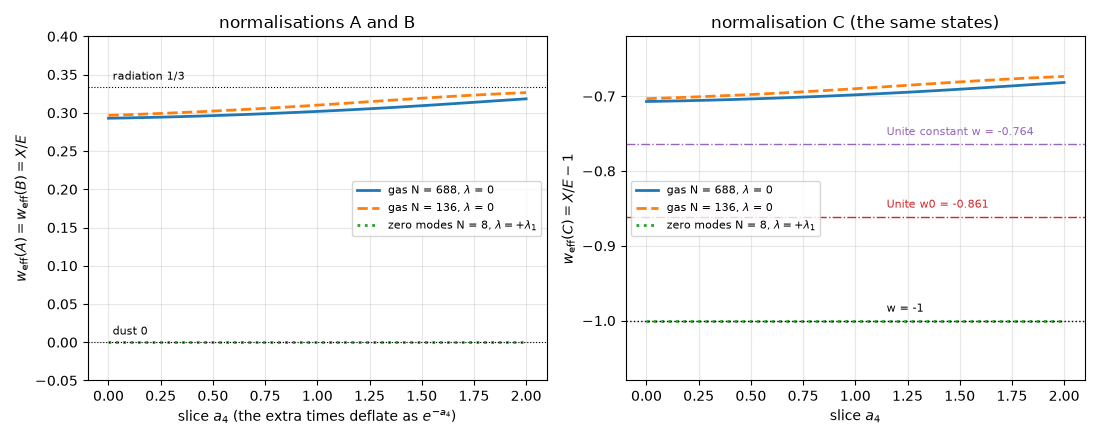

figure saved: <output>/figures/figure1_w_eff_histories.png | sha256 3dd746f892c0382b743ea36b5c7a5432dc49666eff32be4f4e2fc380f44a27fb


In [17]:
def save_and_show(fig, name):
    path = FIG_DIR / name
    fig.savefig(path, format="png", dpi=100, metadata={"Software": None})
    plt.close(fig)
    display(Image(data=path.read_bytes()))
    print("figure saved:", shown(path), "| sha256", sha256(path))


STYLE = {"N688_lam0": ("C0", "-"), "N136_lam0": ("C1", "--"), "N8_lamp1": ("C2", ":")}
LABEL = {"N688_lam0": r"gas N = 688, $\lambda$ = 0", "N136_lam0": r"gas N = 136, $\lambda$ = 0",
         "N8_lamp1": r"zero modes N = 8, $\lambda = +\lambda_1$"}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.4))
for sid, e in EOS.items():
    colour, ls = STYLE[sid]
    ax1.plot(e["a4"], e["wA"], color=colour, ls=ls, lw=2, label=LABEL[sid])
    ax2.plot(e["a4"], e["wC"], color=colour, ls=ls, lw=2, label=LABEL[sid])
ax1.axhline(1 / 3, color="k", lw=0.8, ls=":")
ax1.text(0.02, 1 / 3 + 0.01, "radiation 1/3", fontsize=8)
ax1.axhline(0, color="k", lw=0.8, ls=":")
ax1.text(0.02, 0.01, "dust 0", fontsize=8)
ax1.set_xlabel(r"slice $a_4$ (the extra times deflate as $e^{-a_4}$)")
ax1.set_ylabel(r"$w_\mathrm{eff}(A) = w_\mathrm{eff}(B) = X/E$")
ax1.set_title("normalisations A and B")
ax1.set_ylim(-0.05, 0.4)
ax1.legend(fontsize=8, loc="center right")
ax1.grid(True, alpha=0.3)
for val, txt, col in ((-1.0, "w = -1", "k"), (UNITE["w0"], "Unite w0 = -0.861", "C3"), (UNITE["w_const"], "Unite constant w = -0.764", "C4")):
    ax2.axhline(val, color=col, lw=1, ls="-." if col != "k" else ":")
    ax2.text(1.15, val + 0.012, txt, fontsize=8, color=col)
ax2.set_xlabel(r"slice $a_4$")
ax2.set_ylabel(r"$w_\mathrm{eff}(C) = X/E - 1$")
ax2.set_title("normalisation C (the same states)")
ax2.set_ylim(-1.08, -0.62)
ax2.legend(fontsize=8, loc="center left")
ax2.grid(True, alpha=0.3)
fig.tight_layout()
save_and_show(fig, "figure1_w_eff_histories.png")

### 14.2 Figure 2: mixtures of the gas with a condensate, against the Unite line

$w_\mathrm{eff}(C)$ of the gas (N = 688, $\lambda = 0$) mixed with a condensate, against the observer's scale
factor $a = e^{a_4 - 2}$ (today $a_4 = 2$, CHOSEN), for several CHOSEN gas fractions today, and the mixture
whose $w_\mathrm{eff}(C)$ equals $-0.861$ today (section 11.1). The black line is the Unite CPL line
$w = -0.861 - 0.60(1 - a)$, which falls below $-1$ for $a < 461/600$. As $a$ grows the gas fades, and
every mixture moves DOWN toward the condensate's $-1$ (freezing, $w_a > 0$), while the Unite line moves
UP (thawing, $w_a < 0$): the two slopes have opposite signs.

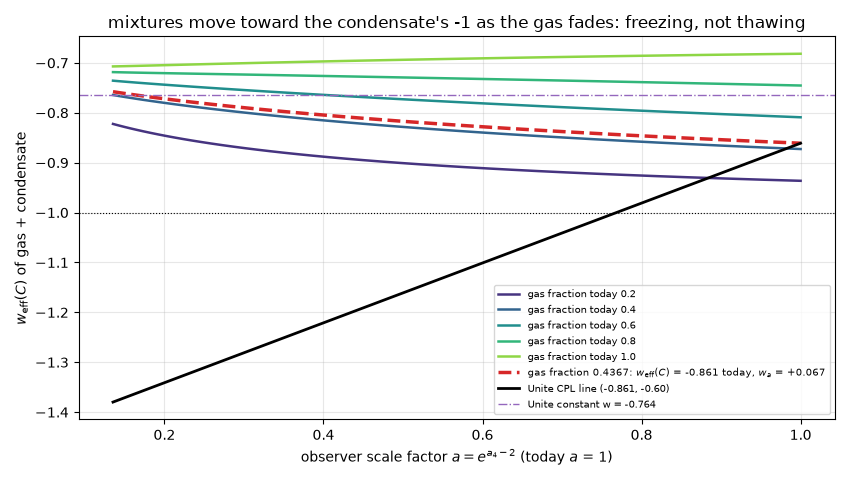

figure saved: <output>/figures/figure2_mixtures.png | sha256 b796eaa803b89a6c8ef074a13396a0476366893bc3474e6a04eaf66315aa3d05


In [18]:
a_obs = np.exp(a4g - 2.0)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for k, f0 in enumerate((0.2, 0.4, 0.6, 0.8, 1.0)):
    Ec = Eg[it] * (1 - f0) / f0
    ax.plot(a_obs, Xg / (Eg + Ec) - 1, color=plt.cm.viridis(0.15 + 0.17 * k), lw=1.8, label=f"gas fraction today {f0:.1f}")
ax.plot(a_obs, Xg / (Eg + Ec861) - 1, color="C3", lw=2.5, ls="--",
        label=f"gas fraction {f861:.4f}: $w_\\mathrm{{eff}}(C)$ = -0.861 today, $w_a$ = {wa861:+.3f}")
aa = np.linspace(a_obs[0], 1.0, 200)
ax.plot(aa, UNITE["w0"] + UNITE["wa"] * (1 - aa), color="k", lw=2, label="Unite CPL line (-0.861, -0.60)")
ax.axhline(-1, color="k", lw=0.8, ls=":")
ax.axhline(UNITE["w_const"], color="C4", lw=1, ls="-.", label="Unite constant w = -0.764")
ax.set_xlabel(r"observer scale factor $a = e^{a_4 - 2}$ (today $a$ = 1)")
ax.set_ylabel(r"$w_\mathrm{eff}(C)$ of gas + condensate")
ax.set_title("mixtures move toward the condensate's -1 as the gas fades: freezing, not thawing")
ax.legend(fontsize=7.5, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_and_show(fig, "figure2_mixtures.png")

### 14.3 Figure 3: the dirac16complex00 populations against the Unite CPL line

Left: $w_\mathrm{eff}(N2)$ of the four models M2 to M5 over $a \in [1/3, 1]$ (the parameters of every model are
CHOSEN; M4 and M5 are solved to reproduce the Unite tangent or fit: by construction, NOT predictions),
the Unite CPL line, and $w = -1$. M2 is freezing, M3 and M4 are thawing but stay above $-1$; M4 touches
the Unite line at $a = 1$ (same tangent). Only M5, with its ghost-like component of negative classical
energy, crosses $-1$ (at $a = 0.779$; the Unite line at $461/600 = 0.768$). Right: the same models
under N1 (= the reading B of section 4.3): M2 is the dark-matter-like law from 1/3 toward 0.

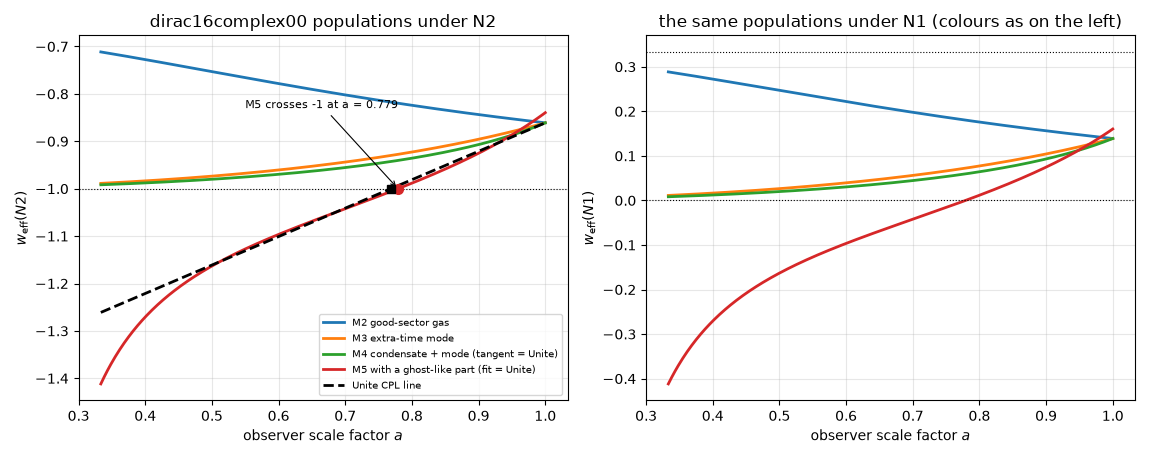

figure saved: <output>/figures/figure3_dirac16complex00_populations.png | sha256 0d393d8b03382d2fd582be2d39f147824f9a2ffdf17c4171ed8ee296af6c243a


In [19]:
a3 = np.linspace(1 / 3, 1.0, 400)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6))
names = {"M2_positive_good_sector_gas": "M2 good-sector gas", "M3_positive_extra_time_mode": "M3 extra-time mode",
         "M4_condensate_plus_extra_time_mode": "M4 condensate + mode (tangent = Unite)",
         "M5_with_ghost_component": "M5 with a ghost-like part (fit = Unite)"}
for k, (name, comps) in enumerate(FLOAT_MODELS.items()):
    vals = [parts(comps, float(x), math.sqrt) for x in a3]
    ax1.plot(a3, [-1 + E / R for R, E, _ in vals], color=f"C{k}", lw=2, label=names[name])
    ax2.plot(a3, [E / R for R, E, _ in vals], color=f"C{k}", lw=2, label=names[name])
ax1.plot(a3, UNITE["w0"] + UNITE["wa"] * (1 - a3), color="k", lw=2, ls="--", label="Unite CPL line")
ax1.axhline(-1, color="k", lw=0.8, ls=":")
ax1.plot([float(a_cross)], [-1], "o", color="C3", ms=7)
ax1.plot([461 / 600], [-1], "s", color="k", ms=6)
ax1.annotate("M5 crosses -1 at a = 0.779", (float(a_cross), -1), (0.55, -0.83), fontsize=8,
             arrowprops={"arrowstyle": "->", "lw": 0.8})
ax1.set_xlabel("observer scale factor $a$")
ax1.set_ylabel(r"$w_\mathrm{eff}(N2)$")
ax1.set_title("dirac16complex00 populations under N2")
ax1.legend(fontsize=7.5, loc="lower right")
ax1.grid(True, alpha=0.3)
ax2.axhline(1 / 3, color="k", lw=0.8, ls=":")
ax2.axhline(0, color="k", lw=0.8, ls=":")
ax2.set_xlabel("observer scale factor $a$")
ax2.set_ylabel(r"$w_\mathrm{eff}(N1)$")
ax2.set_title("the same populations under N1 (colours as on the left)")
ax2.grid(True, alpha=0.3)
fig.tight_layout()
save_and_show(fig, "figure3_dirac16complex00_populations.png")

### 14.4 Figure 4: every candidate in the $(w_0, w_a)$ plane

Each point is one $(w_0, w_a)$ pair computed or re-checked above, against the Unite pair $(-0.861, -0.60)$
(star). Blue: the Kohn-Sham gas under C (tangents at the four CHOSEN "todays" and the three fits). Purple:
the twelve gas + condensate mixtures under C (tangent, today $a_4 = 2$). Black: the condensate under C,
$(-1, 0)$. Green: the dirac16complex00 models under N2 (exact tangents of M2, M3, M4; least-squares fits
over $[1/2, 1]$ of M2 to M5). Points below the dotted line $w_0 + w_a = -1$ have a CPL line that is
phantom in the far past. Only the models CHOSEN to hit the Unite pair (M4 tangent, M5 fit with its
ghost-like part) reach it.

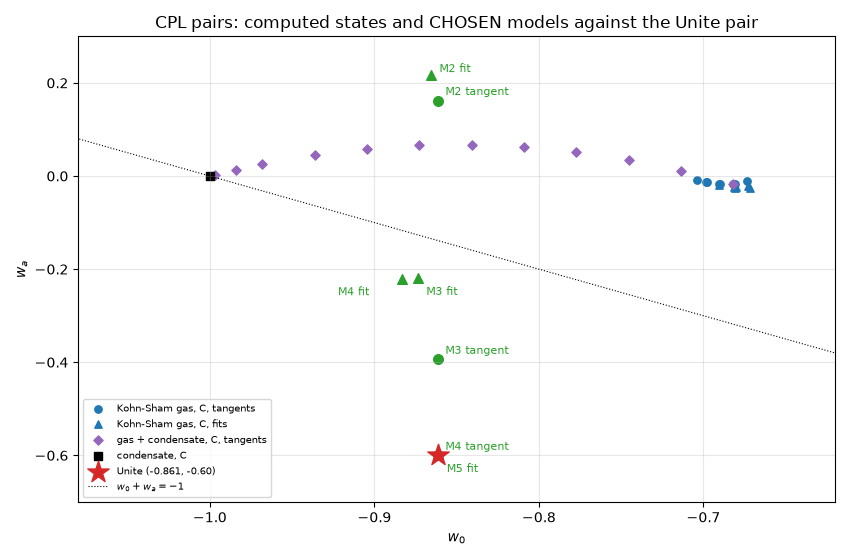

figure saved: <output>/figures/figure4_w0_wa_plane.png | sha256 55d56eac83e106647012ae3a1f952852cc26d5a684328bdfb48d2b382cbcfc0d


In [20]:
fig, ax = plt.subplots(figsize=(8.5, 5.6))
gas_t = [(t["w_eff_C"]["w0"], t["w_eff_C"]["wa"]) for s in ("N688_lam0", "N136_lam0") for t in CPL[s]["cplTangent"]]
gas_f = [(f["w_eff_C"]["w0"], f["w_eff_C"]["wa"]) for s in ("N688_lam0", "N136_lam0") for f in CPL[s]["cplFits"]]
ax.scatter(*zip(*gas_t), color="C0", marker="o", s=28, label="Kohn-Sham gas, C, tangents")
ax.scatter(*zip(*gas_f), color="C0", marker="^", s=28, label="Kohn-Sham gas, C, fits")
mixC = [(m["w_eff_C"]["w0"], m["w_eff_C"]["wa"]) for m in MIX]
ax.scatter(*zip(*mixC), color="C4", marker="D", s=22, label="gas + condensate, C, tangents")
ax.scatter([-1.0], [0.0], color="k", marker="s", s=40, label="condensate, C")
for name, (w0, wa) in TAN00.items():
    ax.scatter([float(w0)], [float(wa)], color="C2", marker="o", s=48)
    ax.annotate(name.split("_")[0] + " tangent", (float(w0), float(wa)), (5, 4), textcoords="offset points", fontsize=8, color="C2")
FIT_LABEL_OFFSET = {"M2": (6, 2), "M3": (6, -12), "M4": (-46, -12), "M5": (6, -12)}
for name in FLOAT_MODELS:
    fit = MODELS[name]["N2"]["fit_a_1/2_to_1"]
    short = name.split("_")[0]
    ax.scatter([float(fit["w0"])], [float(fit["wa"])], color="C2", marker="^", s=48)
    ax.annotate(short + " fit", (float(fit["w0"]), float(fit["wa"])), FIT_LABEL_OFFSET[short], textcoords="offset points",
                fontsize=8, color="C2")
ax.scatter([UNITE["w0"]], [UNITE["wa"]], color="C3", marker="*", s=260, zorder=5, label="Unite (-0.861, -0.60)")
ww = np.linspace(-1.1, -0.6, 10)
ax.plot(ww, -1 - ww, color="k", lw=0.8, ls=":", label="$w_0 + w_a = -1$")
ax.set_xlim(-1.08, -0.62)
ax.set_ylim(-0.7, 0.3)
ax.set_xlabel("$w_0$")
ax.set_ylabel("$w_a$")
ax.set_title("CPL pairs: computed states and CHOSEN models against the Unite pair")
ax.legend(fontsize=7.5, loc="lower left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_and_show(fig, "figure4_w0_wa_plane.png")

### 14.5 Summary of this notebook's checks

The last code cell counts the checks of this notebook (each printed a PASS line above; a failure would
have stopped the notebook at that point) and lists the files written into `<output>` (the 123 result
files of the solver are summarised in one line).

In [21]:
print(f"checks of this notebook: {len(CHECKS)} passed, 0 failed")
runs = sorted(RUN_DIR.glob("*.json"))
print(f"  <output>/ks_runs/*.json: {len(runs)} result files, {sum(p.stat().st_size for p in runs)} bytes")
for path in sorted(p for p in OUT.rglob("*") if p.is_file() and TARGET not in p.parents
                     and "cargo-target" not in p.relative_to(OUT).parts and p.parent != RUN_DIR):
    print(f"  {shown(path):48s} {path.stat().st_size:7d} bytes")

checks of this notebook: 40 passed, 0 failed
  <output>/ks_runs/*.json: 123 result files, 4873129 bytes
  <output>/eos-history-subset.csv                    37220 bytes
  <output>/figures/figure1_w_eff_histories.png       60531 bytes
  <output>/figures/figure2_mixtures.png              65481 bytes
  <output>/figures/figure3_dirac16complex00_populations.png   79878 bytes
  <output>/figures/figure4_w0_wa_plane.png           39932 bytes
  <output>/ks-history-dense-subset.csv               28791 bytes


## 15. What this notebook showed, and what it did not show

**Showed.**

- The Revision Kohn-Sham solver builds without warnings, checks its inputs and runs with the parameters
  of the committed record. 123 states of the dense history (N = 688 and N = 136 without interaction,
  N = 8 with $+\lambda_1$; 41 slices each), solved anew with the arguments of `run_ks_history.py`,
  reproduce the committed rows of `ks-history-dense.csv` character for character, with the same
  occupied levels at every slice.
- Recomputed exactly as `compute_eos.py` does, the equation-of-state rows equal `eos-history.csv`, and
  the CPL tangents, fits, ranges and conservation deviations of the three series equal `eos-summary.json`;
  $dE/da_4 = -3(P_3 - P_t)$ holds to about $10^{-7}$.
- The Kohn-Sham gas is radiation-like: $w_\mathrm{eff}(A) = w_\mathrm{eff}(B) = X/E$ rises from 0.293 toward
  1/3; under the normalisation C the same states read $w_\mathrm{eff}(C)$ between $-0.708$ and $-0.673$
  with a small thawing-sign slope ($|w_a| \le 0.03$), far from the Unite pair $(-0.861, -0.60)$. The interacting
  zero modes are constant ($w_\mathrm{eff}(A) = 0$, $w_\mathrm{eff}(C) = -1$).
- The condensate ratio equals $-0.764$ exactly at the CHOSEN $\lambda S/m = -382/441$ (by construction),
  and the closed formulas of the record (flat massive mode, radiation + condensate with
  $r_0 = 417/583$) are exact. Mixtures of the gas with a condensate are freezing ($w_a > 0$) and the ratio
  scan never comes closer than 0.60 to the Unite pair.
- For dirac16complex00 the tangents of M2 (freezing, $+81037/500000$), M3 (thawing, $-196963/500000$)
  and M4 (exactly the Unite pair, by construction) are exact fractions, and the M5 crossing of $-1$ at
  $a = 0.7791$ is bracketed in exact arithmetic; it exists only because of M5's ghost-like component.
- The six committed dark-sector reports record 30, 5, 13, 9, 49 and 28 checks, all passed.

**Did not show.**

- Neither Hypothesis nor Hypothesis00 is established. Nothing computed here produces the Unite thawing
  pair from a state of the theory: the pair is reached only by the dirac16complex00 models whose
  parameters were SOLVED to reach it (M4's tangent; M5's fit, which also needs a populated ghost-like
  sector of negative classical energy), and those parameters are CHOSEN, not predicted.
- The observer normalisation (A, B or C; N1 or N2) is an ASSUMPTION; the verdict changes by exactly
  $-1$ between them. $a_{4,\mathrm{today}}$ and the gas fractions are CHOSEN.
- The history $a_4 = A H x_4$ is prescribed: the Kohn-Sham gas is a test field without back-reaction and
  not an admissible source of the $a_4$ equations; on this history the observer's expansion reads
  $w_\mathrm{exp} = -1$ exactly. The $Z_2$ brane is ASSUMED and the filling of the positive branch is a
  CONVENTION; only $T = 0$ and $a_4 \in [0, 2]$ are used.
- This notebook re-ran 3 of the 15 series; the other 12 series, the sympy derivation, the independent
  free-gas implementation and both dirac16complex00 implementations are only quoted through their
  committed reports. The dirac16complex00 models rest on the WKB approximation stated in its record, and
  its growing modes (an ill-posed Cauchy problem) are not cured anywhere.
- There is no supernova likelihood: the "fits" are least squares of $w(a)$, not fits to data.